In [96]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import seaborn as sns
sns.set_theme(style="whitegrid", context="talk")
from arch import arch_model
import xgboost as xgb
from tqdm import tqdm
import time
import warnings
from scipy.stats import pearsonr, spearmanr, kendalltau, ks_2samp
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from joblib import Parallel, delayed
from typing import Sequence, List, Dict, Any, Tuple
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
import gc

## Example of price/volatility data

/home/tatiana/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


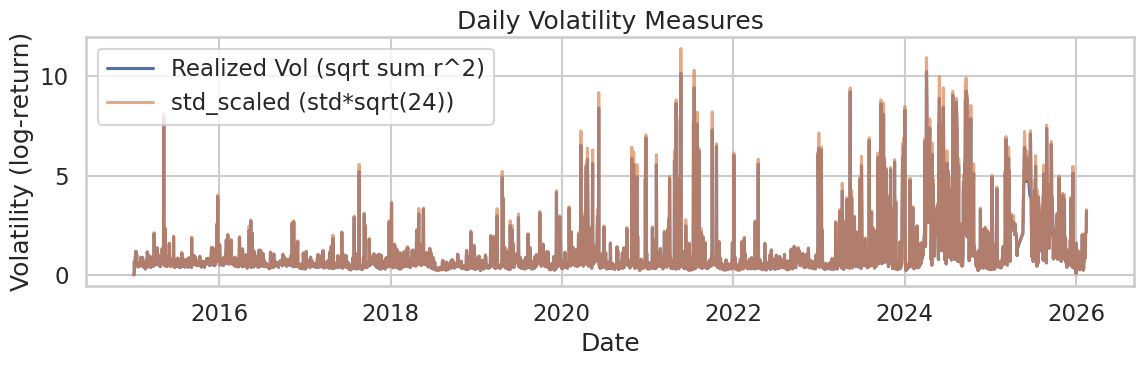

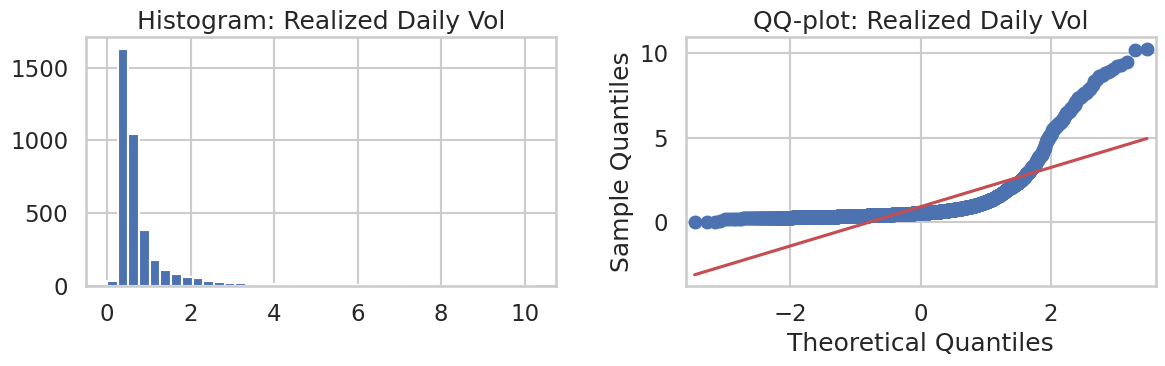

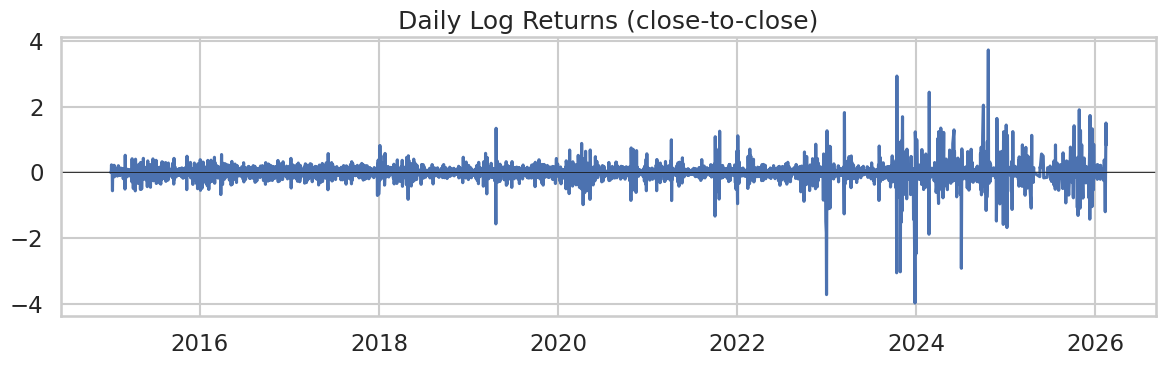

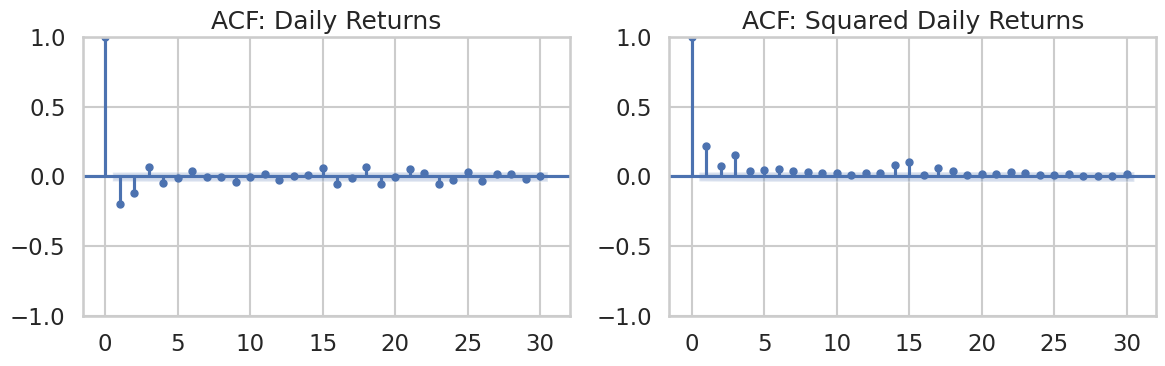

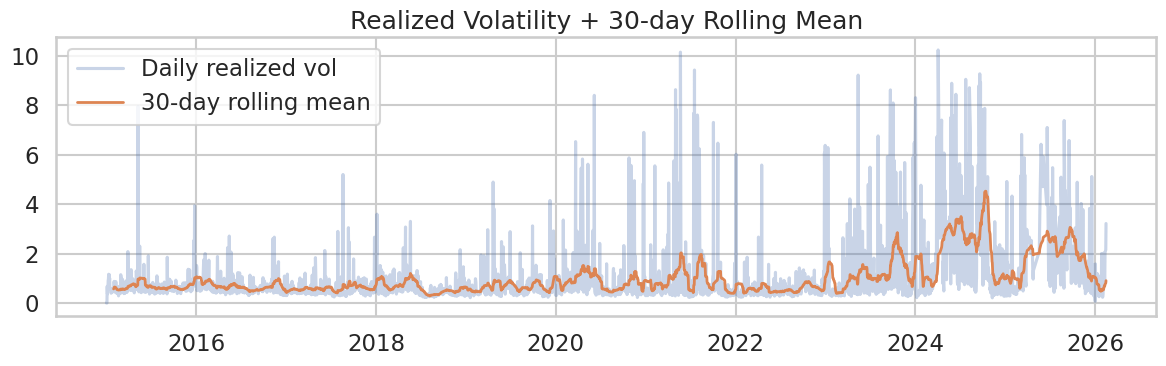

In [18]:
fn = "european_wholesale_electricity_price_data_hourly/France.csv"

# parse dates, prefer local datetime column for daily aggregation
df = pd.read_csv(fn, parse_dates=['Datetime (Local)'])

# columns: Country, ISO3 Code, Datetime (UTC), Datetime (Local), Price (EUR/MWhe)
# keep only the local datetime and price
df = df[['Datetime (Local)', 'Price (EUR/MWhe)']].copy()
df = df.rename(columns={'Datetime (Local)': 'datetime', 'Price (EUR/MWhe)': 'price'})
df = df.sort_values('datetime').set_index('datetime')
df.index = pd.to_datetime(df.index)  # ensure datetime index

# ---------------------------
# Hourly returns
# ---------------------------
# compute log returns (natural log)
df['log_price'] = np.log(df['price'].replace(0, np.nan))
df['hourly_ret'] = df['log_price'].diff()
df = df.dropna(subset=['hourly_ret'])  # drop first NA

# ---------------------------
# Daily volatility measures
# ---------------------------
# Option A: Realized volatility (square-root of sum of squared intraday returns)
# Option B: Daily std of hourly returns scaled by sqrt(24) (if hours per day ~24)
# Guard against days with missing hours (e.g., DST or missing data)
min_hours_required = 20  # drop days with fewer than this many hourly observations

# attach a date column for grouping (local date)
df['date'] = df.index.normalize()  # midnight-normalized date

group = df.groupby('date')

# count hours per day
counts = group['hourly_ret'].count().rename('n_hours')

daily = pd.DataFrame({
    'n_hours': counts,
})

# realized volatility: sqrt(sum(r_i^2))
daily['realized_vol'] = group['hourly_ret'].apply(lambda x: np.sqrt(np.sum(x.values**2)))

# scaled std: std(hourly returns) * sqrt(24)  (common approximation)
daily['std_scaled'] = group['hourly_ret'].std() * np.sqrt(24)

# daily log return using last observation each day (close-to-close)
daily_close = df['log_price'].resample('D').last()
daily['daily_log_return'] = daily_close.diff().reindex(daily.index)

# filter days with too few hours (optional, recommended)
daily = daily[daily['n_hours'] >= min_hours_required]

# drop any rows with NaNs where it matters
daily = daily.dropna(subset=['realized_vol', 'std_scaled', 'daily_log_return'])

# ---------------------------
# Plotting
# ---------------------------
plt.rcParams['figure.figsize'] = (12, 4)

# Time series of realized volatility
plt.figure()
plt.plot(daily.index, daily['realized_vol'], label='Realized Vol (sqrt sum r^2)')
plt.plot(daily.index, daily['std_scaled'], label='std_scaled (std*sqrt(24))', alpha=0.7)
plt.legend()
plt.title('Daily Volatility Measures')
plt.xlabel('Date')
plt.ylabel('Volatility (log-return)')
plt.tight_layout()
plt.show()

# Histogram + QQplot of daily volatility
plt.figure()
plt.subplot(1,2,1)
plt.hist(daily['realized_vol'].dropna(), bins=40)
plt.title('Histogram: Realized Daily Vol')
plt.subplot(1,2,2)
qqplot(daily['realized_vol'].dropna(), line='s', ax=plt.gca())
plt.title('QQ-plot: Realized Daily Vol')
plt.tight_layout()
plt.show()

# Time series of daily returns 
plt.figure()
plt.plot(daily.index, daily['daily_log_return'])
plt.title('Daily Log Returns (close-to-close)')
plt.axhline(0, color='k', linewidth=0.6)
plt.tight_layout()
plt.show()

# ACF of returns and squared returns
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plot_acf(daily['daily_log_return'].dropna(), lags=30, ax=plt.gca(), title='ACF: Daily Returns')
plt.subplot(1,2,2)
plot_acf(daily['daily_log_return'].dropna()**2, lags=30, ax=plt.gca(), title='ACF: Squared Daily Returns')
plt.tight_layout()
plt.show()

# Rolling volatility plot 
plt.figure()
rolling = daily['realized_vol'].rolling(window=30).mean()
plt.plot(daily.index, daily['realized_vol'], alpha=0.3, label='Daily realized vol')
plt.plot(daily.index, rolling, label='30-day rolling mean', linewidth=2)
plt.legend()
plt.title('Realized Volatility + 30-day Rolling Mean')
plt.tight_layout()
plt.show()

# Function block -- to be moved to a class 

## For demo/results please scroll down

### Loading data

In [21]:
def sanitize_col(c: str) -> str:
    """Sanitize a column name"""
    return str(c).strip().replace(' ', '_').replace('/', '_').replace('-', '_')

def load_coupled_panel(germany_file: str, france_file: str) -> pd.DataFrame:
    """
    Load Germany and France CSVs.
    Output: one row per DATE, with DE_* and FR_* columns in same row.
    """
    g = pd.read_csv(germany_file, parse_dates=[0])
    f = pd.read_csv(france_file, parse_dates=[0])

    g.rename(columns={g.columns[0]: 'DATE'}, inplace=True)
    f.rename(columns={f.columns[0]: 'DATE'}, inplace=True)

    g['DATE'] = pd.to_datetime(g['DATE']).dt.normalize()
    f['DATE'] = pd.to_datetime(f['DATE']).dt.normalize()

    def prefix(df, code):
        df = df.copy()
        for c in df.columns:
            if c == 'DATE':
                continue
            df.rename(columns={c: f"{code}_{sanitize_col(c)}"}, inplace=True)
        return df

    g = prefix(g, "DE")
    f = prefix(f, "FR")

    panel = pd.merge(g, f, on="DATE", how="inner")
    panel = panel.sort_values("DATE").reset_index(drop=True)

    return panel

### Building features for ML 

For example, lags or cross-country interactions. 

**Attention**: this version of function is only correct when prediction target is shifted wrt exogenous variables to t+1! So that variables at t are lag-1. Otherwise there is a lookahead bias!

In [ ]:
################### THIS FUNCTION NOW DOES LAGS WITH RESPECT TO TIME T+1!!!! TARGET IS AT T+1! SO LAG-1 IS T, LAG-7 
################### IS T-6 !! CAREFUL WITH HOW THE TARGET IS DEFINED TO AVOID LOOKAHEAD!!!!!

def build_features(panel: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
    df = panel.copy()

    prefixes = ['DE', 'FR']
    core = ['load_MW', 'wind_total', 'solar_total',
            'wind_share', 'solar_share',
            'temp_C', 'wind_speed', 'precip',
            'daily_log_return', 'realized_vol']

    # Lags
    for pref in prefixes:
        for base in core:
            col = f"{pref}_{base}"
            if col not in df.columns:
                continue
            #df[f"{col}_lag1"] = df[col].shift(1)
            df[f"{col}_lag7"] = df[col].shift(6)

    # Rolling means/std 
    for pref in prefixes:
        for base in ['load_MW', 'wind_total', 'solar_total']:
            col = f"{pref}_{base}"
            if col not in df.columns:
                continue
#            df[f"{col}_rm_7"] = df[col].shift(1).rolling(7, min_periods=2).mean()
#            df[f"{col}_std_7"] = df[col].shift(1).rolling(7, min_periods=2).std()
#            df[f"{col}_rm_30"] = df[col].shift(1).rolling(30, min_periods=5).mean()
            df[f"{col}_rm_7"] = df[col].rolling(7, min_periods=2).mean()
            df[f"{col}_std_7"] = df[col].rolling(7, min_periods=2).std()
            df[f"{col}_rm_30"] = df[col].rolling(30, min_periods=5).mean()


    # Volatility features
    for pref in prefixes:
        rcol = f"{pref}_daily_log_return"
        if rcol not in df.columns:
            continue
        #df[f"{rcol}_vol_14"] = df[rcol].shift(1).rolling(14, min_periods=5).std()
        df[f"{rcol}_vol_14"] = df[rcol].rolling(14, min_periods=5).std()

    # Cross-country features 
    if 'DE_load_MW' in df.columns and 'FR_load_MW' in df.columns:
        df['LOAD_IMBALANCE'] = df['DE_load_MW'] - df['FR_load_MW']

    if 'DE_wind_total' in df.columns and 'FR_wind_total' in df.columns:
        df['WIND_IMBALANCE'] = df['DE_wind_total'] - df['FR_wind_total']

    return df

### GARCH(1,1) per-country model, parallelized, rolling windows

In [26]:
def add_garch_parallel(panel: pd.DataFrame,
                       min_obs=250,
                       window=150,          # can be int or dict
                       p=1, q=1,
                       n_jobs=4):
    """
    Fit GARCH(p,q) models per country in parallel,
    store sigma forecasts in panel, and compute metrics
    vs realized volatility columns (DE_realized_vol, FR_realized_vol).

    window:
        - int → same window for all countries
        - dict → e.g. {"DE": 500, "FR": 150}
    """
    df = panel.copy()
    metrics = {}

    # allow per-country window
    if isinstance(window, dict):
        window_map = window
    else:
        window_map = {"DE": window, "FR": window}

    def fit_garch_for_country(pref):
        ret_col = f"{pref}_daily_log_return"
        sigma_col = f"{pref}_garch_sigma"
        realized_col = f"{pref}_realized_vol"

        country_window = window_map.get(pref, window)

        sigmas = np.full(len(df), np.nan)
        rets = df[ret_col].values

        for i in range(len(df)):
            if i < min_obs:
                continue

            hist = rets[max(0, i-country_window):i]
            hist = hist[np.isfinite(hist)]

            effective_min_obs = min(min_obs, country_window)
            
            if len(hist) < effective_min_obs:
                continue

            try:
                am = arch_model(hist, vol='Garch', p=p, q=q, dist='t', rescale=True)
                res = am.fit(disp='off')
                fcast = res.forecast(horizon=1, reindex=False)
                var = fcast.variance.values[-1, 0]
                sigmas[i] = np.sqrt(max(var, 1e-16))
            except:
                continue

        # Compute metrics vs existing realized volatility column
        mask = ~np.isnan(sigmas) & ~np.isnan(df[realized_col])
        if mask.sum() > 0:
            y_pred = sigmas[mask]
            y_true = df.loc[mask, realized_col].values
            ic = spearmanr(y_pred, y_true).correlation
            rmse = float(np.sqrt(np.mean((y_pred - y_true)**2)))
            mae = float(np.mean(np.abs(y_pred - y_true)))
        else:
            ic = rmse = mae = np.nan

        return pref, sigmas, {'spearman_ic': ic, 'rmse': rmse, 'mae': mae}

    # Parallel computation
    results = Parallel(n_jobs=n_jobs)(
        delayed(fit_garch_for_country)(pref) for pref in ['DE', 'FR']
    )

    # Assign computed sigmas back to main df
    for pref, sigmas, m in results:
        df[f"{pref}_garch_sigma"] = sigmas
        metrics[pref] = m

    return df, metrics

### HAR-RV per-country model, parallelized, rolling windows

In [27]:
def add_har_rv_parallel(
    panel: pd.DataFrame,
    min_obs: int = 22,          # minimum history before first HAR forecast
    window: object = 150,       # rolling OLS window; int or dict {"DE": 500, "FR": 150}
    n_jobs: int = 4
) -> tuple:
    """
    Fit rolling HAR-RV models per country in parallel and store
    one-step-ahead forecasts in the panel.

    HAR-RV model (Corsi 2009):
        RV_{t+1} = beta0
                 + beta1 * RV_d_t          (daily:   last observation)
                 + beta2 * RV_w_t          (weekly:  mean of last 5 obs)
                 + beta3 * RV_m_t          (monthly: mean of last 22 obs)
                 + epsilon

    Rolling OLS is estimated on a window of observations.

    OUTPUT COLUMNS (identical names to add_garch_parallel):
        {pref}_garch_sigma  — HAR-RV forecast of RV at t+1
                              (column intentionally keeps the garch_sigma name
                               so the rest of the code works no matter the function used)
    """

    df = panel.copy()

    # Allow per-country window
    if isinstance(window, dict):
        window_map = window
    else:
        window_map = {"DE": window, "FR": window}

    def fit_har_for_country(pref: str):
        rv_col = f"{pref}_realized_vol"
        sigma_col = f"{pref}_garch_sigma"   # <-- intentional: keep existing name
        realized_col = rv_col

        country_window = window_map.get(pref, window if isinstance(window, int) else 150)

        rv = df[rv_col].values.astype(float)
        n = len(rv)
        forecasts = np.full(n, np.nan)

        for i in range(n):
            # Forecast RV at position i using only data up to i-1
            # (the forecast is "what will RV be at t=i, given info through t=i-1")
            if i < max(min_obs, 22):          # need at least 22 obs for monthly component
                continue

            # history: positions 0 … i-1
            start = max(0, i - country_window)
            hist = rv[start:i]                # shape (k,)
            hist_full = rv[max(0, i - 22):i]  # up to 22 obs for monthly component

            # build HAR regressors on historical window for fitting
            # each row j in [start+22 : i] has:
            #   y_j     = rv[j]          (target in-sample)
            #   x1_j    = rv[j-1]        (daily)
            #   x2_j    = mean(rv[j-5:j])  (weekly)
            #   x3_j    = mean(rv[j-22:j]) (monthly)
            fit_start = start + 22            # need 22 lags to build monthly
            fit_end = i                       # exclusive: fit on rv[fit_start..i-1]

            if fit_end - fit_start < 10:      # too few obs → fallback to rolling mean
                forecasts[i] = np.nanmean(hist)
                continue

            # build design matrix for OLS fit
            rows_y = []
            rows_X = []
            for j in range(fit_start, fit_end):
                y_j = rv[j]
                if not np.isfinite(y_j):
                    continue
                x1 = rv[j - 1]
                x2_slice = rv[j - 5:j]
                x3_slice = rv[j - 22:j]
                if not np.isfinite(x1):
                    continue
                x2 = np.nanmean(x2_slice) if len(x2_slice) > 0 else np.nan
                x3 = np.nanmean(x3_slice) if len(x3_slice) > 0 else np.nan
                if not (np.isfinite(x2) and np.isfinite(x3)):
                    continue
                rows_y.append(y_j)
                rows_X.append([1.0, x1, x2, x3])

            if len(rows_y) < 5:               # degenerate — fallback
                forecasts[i] = np.nanmean(hist)
                continue

            Y = np.array(rows_y)
            X = np.array(rows_X)

            try:
                # OLS via normal equations (fast for small matrices)
                beta, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)
            except Exception:
                forecasts[i] = np.nanmean(hist)
                continue

            # forecast for position i using rv at i-1 (the last known value)
            x1_f = rv[i - 1]
            x2_f = np.nanmean(rv[max(0, i - 5):i])
            x3_f = np.nanmean(rv[max(0, i - 22):i])

            if not (np.isfinite(x1_f) and np.isfinite(x2_f) and np.isfinite(x3_f)):
                forecasts[i] = np.nanmean(hist)
                continue

            pred = beta[0] + beta[1] * x1_f + beta[2] * x2_f + beta[3] * x3_f
            # clamp: RV forecasts should be non-negative
            forecasts[i] = max(pred, 1e-12)

        # Compute metrics vs realized volatility (identical to add_garch_parallel)
        mask = ~np.isnan(forecasts) & ~np.isnan(df[realized_col])
        if mask.sum() > 0:
            y_pred = forecasts[mask]
            y_true = df.loc[mask, realized_col].values
            ic   = spearmanr(y_pred, y_true).correlation
            rmse = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))
            mae  = float(np.mean(np.abs(y_pred - y_true)))
        else:
            ic = rmse = mae = np.nan

        return pref, forecasts, {"spearman_ic": ic, "rmse": rmse, "mae": mae}

    # Parallel computation — identical to add_garch_parallel function
    results = Parallel(n_jobs=n_jobs)(
        delayed(fit_har_for_country)(pref) for pref in ["DE", "FR"]
    )

    for pref, forecasts, m in results:
        df[f"{pref}_garch_sigma"] = forecasts    # same column name as GARCH version
        metrics = {}                             

    # rebuild metrics dict in one pass (avoids scoping issue)
    metrics = {pref: m for pref, _, m in results}

    return df, metrics

### Baseline (GARCH/HAR-RV/etc.) diagnostics 

In [95]:
EPS = 1e-12

def baseline_check(df, pref):
    """Check NaNs / coverage and basic Spearman between log realized and log sigma."""
    sig_col = f"{pref}_garch_sigma"
    real_col = f"{pref}_realized_vol"
    ret_col = f"{pref}_daily_log_return"

    print(f"--- {pref} Baseline check ---")
    print("rows:", len(df))
    print("nan sigma:", df[sig_col].isna().sum(), "({:.1%})".format(df[sig_col].isna().mean()))
    print("nan realized:", df[real_col].isna().sum(), "({:.1%})".format(df[real_col].isna().mean()))
    # Valid indices:
    ok = df[sig_col].notna() & df[real_col].notna()
    print("valid pairs:", ok.sum())
    if ok.sum() > 10:
        r = spearmanr(np.log(df.loc[ok, real_col] + EPS), np.log(df.loc[ok, sig_col] + EPS)).correlation
        print("spearman(log realized, log sigma) = {:.4f}".format(r))
    else:
        print("not enough valid pairs to calc spearman")
    print()

def rolling_baseline_metrics(df, pref, window=126):
    """Return a DataFrame with rolling rmse, mae, spearman (rank-corr) between realized and sigma."""
    sig = df[f"{pref}_garch_sigma"]
    real = df[f"{pref}_realized_vol"]
    # log difference residual used elsewhere
    resid = np.log(real + EPS) - np.log(sig + EPS)

    # instantaneous error
    err = sig - real
    abs_err = np.abs(err)
    sq_err = err**2

    # rolling RMSE / MAE
    roll_rmse = (sq_err.rolling(window, min_periods=10).mean()).apply(np.sqrt)
    roll_mae = abs_err.rolling(window, min_periods=10).mean()

    # rolling Spearman via ranks: rank then rolling corr (Spearman = Pearson on ranks)
    ranked_sig = sig.rank()
    ranked_real = real.rank()
    roll_spearman = ranked_sig.rolling(window, min_periods=10).corr(ranked_real)

    out = pd.DataFrame({
        'DATE': df['DATE'],
        'sig': sig,
        'real': real,
        'resid': resid,
        'err': err,
        'roll_rmse': roll_rmse,
        'roll_mae': roll_mae,
        'roll_spearman': roll_spearman
    }).set_index('DATE')
    return out

def baseline_res_diag(df, pref, plot_acf_lags=40):
    """Distribution, QQ-ish and ACF of residual = log(real)-log(sigma)."""
    from scipy import stats
    real = df[f"{pref}_realized_vol"].dropna()
    sig = df[f"{pref}_garch_sigma"].dropna()
    ok_idx = df[f"{pref}_realized_vol"].notna() & df[f"{pref}_garch_sigma"].notna()
    res = np.log(df.loc[ok_idx, f"{pref}_realized_vol"] + EPS) - np.log(df.loc[ok_idx, f"{pref}_garch_sigma"] + EPS)
    print(f"{pref} residual count {len(res)} mean={res.mean():.4f} std={res.std():.4f} skew={pd.Series(res).skew():.4f}")

    # distribution plot
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.hist(res, bins=60, density=True)
    plt.title(f"{pref} residual hist (log real - log sigma)")

    plt.subplot(1,3,2)
    stats.probplot(res, dist="norm", plot=plt)
    plt.title("qq-plot")

    plt.subplot(1,3,3)
    acfs = acf(res, nlags=plot_acf_lags, fft=True, missing='conservative')
    plt.stem(range(len(acfs)), acfs)#, use_line_collection=True)
    plt.title("ACF of residuals")
    plt.tight_layout()

    # bimodality hint using simple 2-means separation (kmeans) to inspect
    try:
        from sklearn.cluster import KMeans
        X = res.values.reshape(-1,1)
        if len(X) > 50:
            km = KMeans(n_clusters=2, random_state=0).fit(X)
            labels = km.labels_
            print("cluster means:", X[labels==0].mean(), X[labels==1].mean())
            print("cluster sizes:", labels.sum(), len(labels)-labels.sum())
        else:
            print("too few residuals for clustering test")
    except Exception as e:
        print("skipped clustering test (need sklearn):", e)

### Creating prediction target -- residual vol after baseline (GARCH/HAR-RV/other baseline)

In [40]:
def make_t_plus_1_targets_winsorized(
    panel: pd.DataFrame,
    de_real_col: str = "DE_realized_vol",
    de_garch_col: str = "DE_garch_sigma",   # works for both GARCH and HAR-RV (same name)
    fr_real_col: str = "FR_realized_vol",
    fr_garch_col: str = "FR_garch_sigma",
    winsor_pct: float = 0.01,               # symmetric winsorization at [pct, 1-pct]
    clip_zeros: bool = True,                # replace realized_vol == 0 with NaN before log
    verbose: bool = True
) -> pd.DataFrame:
    """
    1. clip_zeros: set realized_vol == 0 (or very close) to NaN before taking log.
    2. winsor_pct: after computing log-residuals, symmetrically winsorize
       at the [winsor_pct, 1-winsor_pct] quantiles (default 1%/99%).
       This is applied BEFORE the t+1 shift
    """
    EPS = 1e-12

    df = panel.copy().sort_values("DATE").reset_index(drop=True)

    def _safe_log_resid(real_col, baseline_col):
        rv  = df[real_col].astype(float).copy()
        sig = df[baseline_col].astype(float).copy()

        if clip_zeros:
            # treat very-near-zero realized vol as missing
            # (log of 0 is -inf; these days carry no usable information)
            rv[rv < 1e-6] = np.nan

        log_rv  = np.log(rv  + EPS)
        log_sig = np.log(sig + EPS)
        resid   = log_rv - log_sig

        if winsor_pct > 0.0:
            lo = resid.quantile(winsor_pct)
            hi = resid.quantile(1.0 - winsor_pct)
            n_clipped = int(((resid < lo) | (resid > hi)).sum())
            resid = resid.clip(lower=lo, upper=hi)
            if verbose:
                prefix = real_col.split("_")[0]
                print(
                    f"[winsor] {prefix}: clipped {n_clipped} observations "
                    f"| lo={lo:.3f}  hi={hi:.3f}"
                )

        return resid

    de_resid = _safe_log_resid(de_real_col, de_garch_col)
    fr_resid = _safe_log_resid(fr_real_col, fr_garch_col)

    # shift -1: target at row t is the residual at row t+1
    df["DE_residual_target"] = de_resid.shift(-1)
    df["FR_residual_target"] = fr_resid.shift(-1)

    if verbose:
        for col in ["DE_residual_target", "FR_residual_target"]:
            s = df[col].dropna()
            print(
                f"[target stats] {col}: n={len(s)}  "
                f"mean={s.mean():.3f}  std={s.std():.3f}  "
                f"skew={s.skew():.3f}  "
                f"[{s.quantile(0.01):.2f}, {s.quantile(0.99):.2f}]"
            )

    return df

### Exp. window XGBoost feature selector

In [80]:
SEED = 42
np.random.seed(SEED)

def feature_selection(
    df: pd.DataFrame,
    features: List[str] = None,
    target_de: str = "DE_residual_target",
    target_fr: str = "FR_residual_target",
    min_train_days: int = 280,
    test_horizon: int = 21,
    gap_days: int = 1,
    prefilter_top_k: int = 15,
    max_features: int = 10,
    xgb_params_prefilter: Dict[str, Any] = None,
    n_jobs: int = -1,
    freq_threshold: float = 0.6,   # keep features appearing in >= fraction of folds
    verbose: bool = True
) -> Tuple[List[str], Dict[str, Any]]:
    """
    Expanding-window stability selection for prefixed DE_/FR_ features.
    Returns (selected_union_prefixed, diagnostics_dict).
    diagnostics contains per-fold train/test metrics, selection counts, mean importances.

    NOTE: If `features` is None, features are autodetected from input dataframe by excluding
    a small set of leak / meta columns (see exclude_prefixes).
    """
    # default xgb params (regularized)
    if xgb_params_prefilter is None:
        xgb_params_prefilter = {
            "objective": "reg:squarederror",
            "eval_metric": "rmse",
            "max_depth": 3,
            "eta": 0.03,
            "subsample": 0.6,
            "colsample_bytree": 0.5,
            "lambda": 300,
            "alpha": 10,
            "min_child_weight": 30,
            "seed": SEED,
            "nthread": 1,
            "verbosity": 0
        }

    # ----------------------------
    # FEATURE AUTODETECTION (only change)
    # ----------------------------
    # If user passed features explicitly, respect it. Otherwise build from df columns
    # by excluding likely leakage / meta columns.
    if features is None:
        exclude_prefixes = [
            # general meta
            "DATE",
            # targets
            target_de, target_fr,
            "DE_garch_sigma", "FR_garch_sigma",
            "DE_realized_vol", "FR_realized_vol",
            # country flag etc
            "COUNTRY", "COUNTRY_FLAG"
        ]

        # Candidate feature columns: any column not starting with any exclude token
        candidate_cols = []
        for col in df.columns:
            skip = False
            for ex in exclude_prefixes:
                # match exact column names or prefix matches where useful
                if col == ex or col.startswith(ex):
                    skip = True
                    break
            if not skip:
                candidate_cols.append(col)

        # keep only prefixed DE_/FR_ columns
        features_de = [c for c in candidate_cols if c.startswith("DE_")]
        features_fr = [c for c in candidate_cols if c.startswith("FR_")]
        features = features_de + features_fr
    else:
        features_de = [f for f in features if f.startswith("DE_")]
        features_fr = [f for f in features if f.startswith("FR_")]

    # prepare
    df = df.sort_values("DATE").reset_index(drop=True)
    unique_dates = np.sort(df["DATE"].unique())
    starts = list(range(min_train_days, len(unique_dates) - gap_days - test_horizon + 1, test_horizon))
    if len(starts) == 0:
        raise ValueError("Date range too small or min_train_days/test_horizon settings incompatible.")

    # helpers
    def safe_spearman(x_arr, y_arr):
        try:
            if len(x_arr)==0 or len(y_arr)==0: return 0.0
            if np.nanstd(x_arr) < 1e-12 or np.nanstd(y_arr) < 1e-12: return 0.0
            r = spearmanr(x_arr, y_arr).correlation
            return 0.0 if np.isnan(r) else float(r)
        except Exception:
            return 0.0

    def evaluate_preds(y_true, preds):
        mask = (~np.isnan(y_true)) & (~np.isnan(preds))
        if mask.sum() == 0:
            return {"n":0, "pooled_ic":np.nan, "rmse":np.nan, "mae":np.nan}
        y = np.array(y_true)[mask]; p = np.array(preds)[mask]
        return {"n": len(y), "pooled_ic": safe_spearman(p, y), "rmse": float(np.sqrt(mean_squared_error(y, p))), "mae": float(mean_absolute_error(y, p))}

    # fold worker (per fold do both countries)
    def run_fold(i):
        train_dates = unique_dates[:i]
        test_dates = unique_dates[i + gap_days : i + gap_days + test_horizon]
        if len(test_dates) == 0:
            return None
        train_mask = df["DATE"].isin(train_dates)
        test_mask = df["DATE"].isin(test_dates)

        out = {
            "fold_start_idx": i,
            "train_from": train_dates[0],
            "train_until": train_dates[-1],
            "test_from": test_dates[0],
            "test_to": test_dates[-1],
            "DE": {},
            "FR": {}
        }

        # per-country routine
        def _country_select(prefix_feats, target_col):
            res = {
                "prefilter_scores": [],
                "prefilter_feats": [],
                "selected_feats": [],
                "importance": {},
                "train_metrics": None,
                "test_metrics": None
            }
            if target_col not in df.columns:
                return res

            # compute pooled univariate ic on train only
            scores = []
            train_df = df.loc[train_mask]
            for feat in prefix_feats:
                x = train_df[feat].values if feat in train_df.columns else np.array([])
                y = train_df[target_col].values
                mask = np.isfinite(x) & np.isfinite(y)
                ic = safe_spearman(x[mask], y[mask]) if mask.sum()>0 else 0.0
                scores.append((feat, ic))
            scores.sort(key=lambda kv: abs(kv[1]), reverse=True)
            res["prefilter_scores"] = scores
            prefilter_feats = [f for f,_ in scores[:prefilter_top_k]]
            res["prefilter_feats"] = prefilter_feats

            # if no features or no train labels, return
            if len(prefilter_feats) == 0:
                return res
            y_train = df.loc[train_mask, target_col]
            mask_train = y_train.notna()
            X_train = df.loc[train_mask, prefilter_feats].loc[mask_train].copy()
            y_train = y_train.loc[mask_train].copy()
            if len(X_train) == 0:
                return res

            # train xgboost for fold selection
            try:
                dtrain = xgb.DMatrix(X_train, label=y_train, missing=np.nan)
                booster = xgb.train(xgb_params_prefilter, dtrain, num_boost_round=600, verbose_eval=False)
                importance = booster.get_score(importance_type="gain") or booster.get_score(importance_type="weight")
            except Exception as e:
                # training failed for this fold
                return res

            res["importance"] = importance
            # rank by importance pick top max_features
            feat_import_sorted = sorted(prefilter_feats, key=lambda fv: importance.get(fv, 0.0), reverse=True)
            selected = feat_import_sorted[:max_features]
            res["selected_feats"] = selected

            # train & evaluate on train (pooled) for diagnostics
            preds_train = booster.predict(xgb.DMatrix(X_train, missing=np.nan))
            res["train_metrics"] = evaluate_preds(y_train.values, preds_train)

            # evaluate on fold test (rows where target exists)
            y_test = df.loc[test_mask, target_col]

            # IMPORTANT: booster was trained on prefilter_feats, so we must
            # pass the same feature set at prediction time.
            
            if len(prefilter_feats) > 0:
                X_test_full = df.loc[test_mask, prefilter_feats].copy()
            
                # ensure same column order as training
                X_test_full = X_test_full.reindex(columns=prefilter_feats)
            
                preds_test = booster.predict(
                    xgb.DMatrix(X_test_full, missing=np.nan)
                )
            
                res["test_metrics"] = evaluate_preds(y_test.values, preds_test)
            else:
                res["test_metrics"] = {"n":0, "pooled_ic":np.nan, "rmse":np.nan, "mae":np.nan}

            return res

        out["DE"] = _country_select(features_de, target_de)
        out["FR"] = _country_select(features_fr, target_fr)
        return out

    # run folds (parallel)
    results = Parallel(n_jobs=n_jobs)(delayed(run_fold)(i) for i in starts)
    results = [r for r in results if r is not None]
    n_folds = len(results)
    if n_folds == 0:
        raise ValueError("No folds produced.")

    # aggregate selections and importances
    sel_counts_de = {}
    sel_counts_fr = {}
    agg_importance_de = {}
    agg_importance_fr = {}
    fold_level_metrics = []

    for r in results:
        # DE
        de = r["DE"]
        # record fold metrics
        fold_level_metrics.append({
            "train_until": r["train_until"],
            "test_from": r["test_from"],
            "test_to": r["test_to"],
            "DE_train_n": de.get("train_metrics", {}).get("n", 0),
            "DE_train_ic": de.get("train_metrics", {}).get("pooled_ic", np.nan),
            "DE_train_rmse": de.get("train_metrics", {}).get("rmse", np.nan),
            "DE_test_n": de.get("test_metrics", {}).get("n", 0),
            "DE_test_ic": de.get("test_metrics", {}).get("pooled_ic", np.nan),
            "DE_test_rmse": de.get("test_metrics", {}).get("rmse", np.nan),
        })
        for f in de.get("selected_feats", []):
            sel_counts_de[f] = sel_counts_de.get(f, 0) + 1
        for k,v in (de.get("importance") or {}).items():
            agg_importance_de[k] = agg_importance_de.get(k, 0.0) + float(v)

        # FR
        fr = r["FR"]
        fold_level_metrics[-1].update({
            "FR_train_n": fr.get("train_metrics", {}).get("n", 0),
            "FR_train_ic": fr.get("train_metrics", {}).get("pooled_ic", np.nan),
            "FR_train_rmse": fr.get("train_metrics", {}).get("rmse", np.nan),
            "FR_test_n": fr.get("test_metrics", {}).get("n", 0),
            "FR_test_ic": fr.get("test_metrics", {}).get("pooled_ic", np.nan),
            "FR_test_rmse": fr.get("test_metrics", {}).get("rmse", np.nan),
        })
        for f in fr.get("selected_feats", []):
            sel_counts_fr[f] = sel_counts_fr.get(f, 0) + 1
        for k,v in (fr.get("importance") or {}).items():
            agg_importance_fr[k] = agg_importance_fr.get(k, 0.0) + float(v)

    # normalize aggregated importance by number of folds where present
    mean_importance_de = {k: v / float(n_folds) for k,v in agg_importance_de.items()}
    mean_importance_fr = {k: v / float(n_folds) for k,v in agg_importance_fr.items()}

    # compute selection frequency
    freq_de = {k: sel_counts_de.get(k, 0) / float(n_folds) for k in features_de}
    freq_fr = {k: sel_counts_fr.get(k, 0) / float(n_folds) for k in features_fr}

    # choose stable features based on freq_threshold or at least top by frequency if none meet threshold
    stable_de = [f for f,frq in freq_de.items() if frq >= freq_threshold]
    stable_fr = [f for f,frq in freq_fr.items() if frq >= freq_threshold]

    # fallback: if stable empty, pick top-k by frequency up to max_features
    def fallback_top(freq_map, k):
        # choose correct importance map depending on feature origin
        importance_map = mean_importance_de if any(k in mean_importance_de for k in freq_map) else mean_importance_fr
        sorted_by_freq = sorted(freq_map.items(), key=lambda kv: (kv[1], importance_map.get(kv[0],0.0)), reverse=True)
        return [kv[0] for kv in sorted_by_freq[:k]]

    if len(stable_de) == 0:
        stable_de = fallback_top(freq_de, max_features)
    if len(stable_fr) == 0:
        stable_fr = fallback_top(freq_fr, max_features)

    # cap to max_features each
    stable_de = stable_de[:max_features]
    stable_fr = stable_fr[:max_features]

    # union
    selected_union = list(dict.fromkeys(stable_de + stable_fr))

    diagnostics = {
        "n_folds": n_folds,
        "folds": pd.DataFrame(fold_level_metrics),
        "freq_de": freq_de,
        "freq_fr": freq_fr,
        "mean_importance_de": mean_importance_de,
        "mean_importance_fr": mean_importance_fr,
        "stable_de": stable_de,
        "stable_fr": stable_fr,
        "selected_union": selected_union,
        "raw_fold_results": results
    }



    # ---------- print diagnostics ----------
    if verbose:
        folds_df = diagnostics["folds"]
        n_folds = diagnostics["n_folds"]

        # avg prefilter kept / avg selected per fold (DE / FR) from raw_fold_results
        raw = diagnostics.get("raw_fold_results", [])
        pref_counts_de = []
        sel_counts_de = []
        pref_counts_fr = []
        sel_counts_fr = []
        for r in raw:
            de = r.get("DE", {})
            fr = r.get("FR", {})
            pref_counts_de.append(len(de.get("prefilter_feats", [])))
            sel_counts_de.append(len(de.get("selected_feats", [])))
            pref_counts_fr.append(len(fr.get("prefilter_feats", [])))
            sel_counts_fr.append(len(fr.get("selected_feats", [])))

        avg_prefilter_de = float(np.mean(pref_counts_de)) if len(pref_counts_de)>0 else 0
        avg_selected_de = float(np.mean(sel_counts_de)) if len(sel_counts_de)>0 else 0
        avg_prefilter_fr = float(np.mean(pref_counts_fr)) if len(pref_counts_fr)>0 else 0
        avg_selected_fr = float(np.mean(sel_counts_fr)) if len(sel_counts_fr)>0 else 0

        # fold-level aggregated train / test metrics (mean across folds)
        def _col_mean(df, col):
            return float(df[col].dropna().mean()) if (col in df and df[col].notna().sum()>0) else np.nan

        de_train_ic_mean = _col_mean(folds_df, "DE_train_ic")
        de_test_ic_mean  = _col_mean(folds_df, "DE_test_ic")
        de_train_rmse_mean = _col_mean(folds_df, "DE_train_rmse")
        de_test_rmse_mean  = _col_mean(folds_df, "DE_test_rmse")

        fr_train_ic_mean = _col_mean(folds_df, "FR_train_ic")
        fr_test_ic_mean  = _col_mean(folds_df, "FR_test_ic")
        fr_train_rmse_mean = _col_mean(folds_df, "FR_train_rmse")
        fr_test_rmse_mean  = _col_mean(folds_df, "FR_test_rmse")

        # stable selections & union
        stable_de = diagnostics.get("stable_de", [])
        stable_fr = diagnostics.get("stable_fr", [])
        selected_union = diagnostics.get("selected_union", [])

        # mean importance (sorted) helper
        mean_imp_de = diagnostics.get("mean_importance_de", {})
        mean_imp_fr = diagnostics.get("mean_importance_fr", {})
        top_imp_de = sorted(mean_imp_de.items(), key=lambda kv: kv[1], reverse=True)[:10]
        top_imp_fr = sorted(mean_imp_fr.items(), key=lambda kv: kv[1], reverse=True)[:10]

        print("\n=== FEATURE SELECTION DIAGNOSTICS ===")
        print("Folds:", n_folds)
        print(f"Avg prefilter kept: DE={avg_prefilter_de:.1f}, FR={avg_prefilter_fr:.1f}")
        print(f"Avg selected (per fold): DE={avg_selected_de:.1f}, FR={avg_selected_fr:.1f}")
        print("Union selected count:", len(selected_union))

        print("\n--- Fold-averaged pooled metrics (mean over folds) ---")
        print("DE: train pooled IC / RMSE  :", np.round(de_train_ic_mean, 4), np.round(de_train_rmse_mean, 4))
        print("DE: test  pooled IC / RMSE  :", np.round(de_test_ic_mean, 4), np.round(de_test_rmse_mean, 4))
        print("FR: train pooled IC / RMSE  :", np.round(fr_train_ic_mean, 4), np.round(fr_train_rmse_mean, 4))
        print("FR: test  pooled IC / RMSE  :", np.round(fr_test_ic_mean, 4), np.round(fr_test_rmse_mean, 4))

        print("\nTop stable DE selected features (stable_de):", stable_de)
        print("Top stable FR selected features (stable_fr):", stable_fr)
        print("Final union (selected_union):", selected_union)

        print("\nTop mean importance (DE):")
        for f, v in top_imp_de:
            print(" ", f, ":", float(v))
        print("\nTop mean importance (FR):")
        for f, v in top_imp_fr:
            print(" ", f, ":", float(v))


    return selected_union, diagnostics

### Gaussian Hidden Markov Model for regime detection

In [36]:
def detect_markov_regime(
    df: pd.DataFrame,
    residual_col: str,
    n_states: int = 2,
    scale: bool = True,
    random_state: int = 42
):
    """
    Regime detection using Gaussian HMM.
    Returns:
        df with regime labels + probabilities
        regime diagnostics dict
    """

    data = df[[residual_col]].dropna().copy()
    X = data.values

    if scale:
        scaler = StandardScaler()
        X = scaler.fit_transform(X)

    model = GaussianHMM(
        n_components=n_states,
        covariance_type="full",
        n_iter=1000,
        random_state=random_state
    )

    model.fit(X)

    hidden_states = model.predict(X)
    probs = model.predict_proba(X)

    # attach results
    data["regime"] = hidden_states
    for i in range(n_states):
        data[f"regime_prob_{i}"] = probs[:, i]

    hidden_states_int = hidden_states.astype(int)

    # diagnostics
    diagnostics = {
        "transition_matrix": model.transmat_,
        "means": model.means_.flatten(),
        "covariances": model.covars_.flatten(),
        #"state_counts": np.bincount(hidden_states)
        "state_counts": np.bincount(hidden_states_int, minlength=n_states)
    }

    return data, diagnostics

def compute_acf_by_regime(df, residual_col, regime_col, max_lag=5):
    results = {}

    for regime in sorted(df[regime_col].dropna().unique()):
        subset = df[df[regime_col] == regime][residual_col].dropna().values
        
        if len(subset) < max_lag + 5:
            results[regime] = {"acf": None, "n_obs": len(subset)}
            continue
        
        acf_vals = acf(subset, nlags=max_lag, fft=False)
        
        results[regime] = {
            "n_obs": len(subset),
            "acf_lag1": float(acf_vals[1]),
            "acf_full": acf_vals
        }

    return results

### Main ML function -- exp.window XGBoost

- Training/prediction of volatility residuals
- Supports HMM regime detection outputs (optional for each country)
- For now HMM output is fed as a feature; might consider separate per-regime models
- Per-country modeling
- Parallelized

In [138]:
SEED = 42

def _extract_smoothed_probs(markov_res, train_index, k_regimes=2):
    """
    Adapter for markov outputs. Supports the output of
    `detect_markov_regime` which returns (data, diagnostics_dict),
    where data has index = dates of non-na observations and columns:
      - 'regime' (discrete labels)
      - 'regime_prob_0', 'regime_prob_1', ...
      Tries to look for outputs if the function changed.
    Returns:
      df_sm: DataFrame indexed by `train_index` with columns ['state_0', ...] (length == len(train_index))
             (rows without fitted probs are NaN)
      last_filtered: 1D numpy array length k_regimes with the last posterior prob from training (floats).
    On failure returns (None, None).
    """
    try:
        # Accept either (data, diag) tuple or data alone
        if isinstance(markov_res, (tuple, list)) and len(markov_res) >= 1:
            maybe_df = markov_res[0]
        else:
            maybe_df = markov_res

        # If the returned object is a DataFrame (detect_markov_regime -> data), good
        if isinstance(maybe_df, pd.DataFrame):
            prob_df = maybe_df.copy()
        elif isinstance(maybe_df, dict):
            # a dict with 'data' or similar
            for key in ('data', 'df', 'probs', 'results'):
                if key in maybe_df and isinstance(maybe_df[key], pd.DataFrame):
                    prob_df = maybe_df[key].copy()
                    break
            else:
                return None, None
        else:
            return None, None

        # Find probability columns produced by HMM 
        prob_cols = [c for c in prob_df.columns if c.startswith('regime_prob_')]

        # fallback: columns like 'state_0', 'state_1' or numeric-prob-looking columns
        if len(prob_cols) == 0:
            prob_cols = [c for c in prob_df.columns if c.startswith('state_')]
        if len(prob_cols) == 0:
            # try to detect columns with values in [0,1] and row-wise sum ~1
            candidate = []
            for c in prob_df.columns:
                col = pd.to_numeric(prob_df[c], errors='coerce')
                if col.dropna().between(0, 1).all():
                    candidate.append(c)
            if candidate:
                ssum = prob_df[candidate].sum(axis=1, skipna=True)
                if ((np.isfinite(ssum)) & (np.abs(ssum - 1.0) < 0.01)).sum() > 0:
                    prob_cols = candidate

        if len(prob_cols) == 0:
            # nothing sensible found
            return None, None

        # Ensure prob_df index is datetime-like (so reindexing by dates works predictably)
        try:
            prob_df.index = pd.to_datetime(prob_df.index)
        except Exception:
            pass

        # Build df_sm indexed by train_index (train_index is expected to be dates)
        train_index_dt = pd.to_datetime(train_index)
        df_sm = pd.DataFrame(index=train_index_dt, columns=[f"state_{i}" for i in range(k_regimes)], dtype=float)

        # Map prob columns into df_sm: attempt to detect trailing integer in column names
        import re
        def _col_to_idx(colname):
            m = re.search(r'(\d+)\D*$', colname)
            return int(m.group(1)) if m else None

        mapped = []
        for c in prob_cols:
            idx = _col_to_idx(c)
            mapped.append((c, idx))
        mapped_sorted = sorted(mapped, key=lambda x: (x[1] is None, x[1] if x[1] is not None else 0))

        # Fill df_sm columns from available prob columns (truncate/pad to k_regimes)
        for j, (colname, colidx) in enumerate(mapped_sorted[:k_regimes]):
            target_col = f"state_{j}"
            # reindex prob column to full train_index (this will put NaN where no prob available)
            aligned = prob_df[colname].reindex(train_index_dt)
            df_sm[target_col] = pd.to_numeric(aligned, errors='coerce').astype(float)

        # last_filtered: last non-all-NaN row in original prob_df (not the reindexed df_sm)
        last_row = prob_df.dropna(how='all')
        if last_row.shape[0] == 0:
            # no probabilities at all
            return df_sm, np.full(k_regimes, np.nan, dtype=float)

        # Pick last row's prob columns in the same order we mapped (mapped_sorted)
        last_vals_list = []
        for (colname, _) in mapped_sorted[:k_regimes]:
            val = last_row.iloc[-1].get(colname, np.nan)
            try:
                last_vals_list.append(float(val))
            except Exception:
                last_vals_list.append(np.nan)
        last_vals = np.asarray(last_vals_list, dtype=float)

        # pad/truncate
        if last_vals.size < k_regimes:
            last_filtered = np.pad(last_vals, (0, k_regimes - last_vals.size), constant_values=np.nan)
        else:
            last_filtered = last_vals[:k_regimes]

        return df_sm, np.asarray(last_filtered).astype(float)

    except Exception:
        return None, None


def detect_regime_change_from_series(series: pd.Series,
                                     window_short: int = 21,
                                     window_long: int = 252,
                                     z_thresh: float = 3.0,
                                     persistence_days: int = 3) -> pd.Series:
    """
    Kept for compatibility but NOT used when markov is enabled.
    Simple detection: compare short-mean vs long-mean normalized by long-std.
    """
    s = series.copy().sort_index()
    if s.dropna().shape[0] < max(30, window_short):
        return pd.Series(False, index=s.index)
    long_mean = s.rolling(window_long, min_periods=max(30, int(window_long/4))).mean()
    long_std  = s.rolling(window_long, min_periods=max(30, int(window_long/4))).std().replace(0, 1e-12)
    short_mean = s.rolling(window_short, min_periods=5).mean()
    z = (short_mean - long_mean) / long_std
    flag = (z.abs() > z_thresh).astype(int)
    pers = flag.rolling(persistence_days, min_periods=1).sum()
    is_change = (pers >= persistence_days)
    return is_change.fillna(False).astype(bool)


def two_regime_expanding_cv_per_country(
    df: pd.DataFrame,
    features: List[str],
    target_de: str = "DE_residual_target",
    target_fr: str = "FR_residual_target",
    min_train_days: int = 280,
    test_horizon: int = 21,
    gap_days: int = 0,
    xgb_params: Dict[str, Any] = None,
    n_jobs: int = 4,
    detect_kwargs: Dict[str, Any] = None,
    min_samples_per_regime: int = 50,
    use_markov: Dict[str, bool] = None,
    k_regimes: int = 2
) -> (pd.DataFrame, Dict[str, Any]):
    """
    Expanding-window CV per-country. Optional Markov-smoothed probability features 
    added to the per-country feature sets.
    - use_markov: dict e.g. {'DE': False, 'FR': True}
    """

    if xgb_params is None:
        xgb_params = {
            'objective': 'reg:squarederror',
            'eval_metric': 'rmse',
            'max_depth': 3,
            'eta': 0.02,
            'subsample': 0.6,
            'colsample_bytree': 0.6,
            'lambda': 20,
            'alpha': 5,
            'min_child_weight': 30,
            'seed': SEED,
            # ensure single-thread inside worker processes to avoid over-subscription
            'nthread': 1,
            'verbosity': 0
        }
    if detect_kwargs is None:
        detect_kwargs = dict(window_short=21, window_long=252, z_thresh=3.0, persistence_days=3)
    if use_markov is None:
        use_markov = {'DE': False, 'FR': False}

    df = df.sort_values('DATE').reset_index(drop=True)
    unique_dates = np.sort(df['DATE'].unique())

    # split features by prefix (base lists; will copy inside fold)
    features_de_base = [f for f in features if f.startswith("DE_")]
    features_fr_base = [f for f in features if f.startswith("FR_")]
    if len(features_de_base) == 0 or len(features_fr_base) == 0:
        raise ValueError("features must contain both DE_ and FR_ prefixed names.")

    def safe_spearman(a, b):
        try:
            return float(spearmanr(a, b).correlation)
        except Exception:
            return np.nan

    def train_xgb_safe(X, y):
        """
        Train an XGBoost model on X,y after sanitizing (drop NaN/inf labels and matching X rows).
        Returns model or None and diagnostics (train_pred, val_pred, y_tr, y_val).
        """
        if X.shape[0] == 0:
            return None
        y_ser = pd.Series(y.values, index=X.index)
        mask = y_ser.notna() & np.isfinite(y_ser)
        if mask.sum() == 0:
            return None
        X_clean = X.loc[mask]
        y_clean = y_ser.loc[mask].astype(float)
        if y_clean.shape[0] < min_samples_per_regime:
            return None

        val_size = max(int(0.15 * len(X_clean)), 20)
        if len(X_clean) <= val_size:
            return None

        X_tr = X_clean.iloc[:-val_size]
        y_tr = y_clean.iloc[:-val_size]
        X_val = X_clean.iloc[-val_size:]
        y_val = y_clean.iloc[-val_size:]

        dtrain = xgb.DMatrix(X_tr, label=y_tr, missing=np.nan)
        dval = xgb.DMatrix(X_val, label=y_val, missing=np.nan)
        try:
            m = xgb.train(xgb_params, dtrain, num_boost_round=2000,
                          evals=[(dval, 'val')], early_stopping_rounds=50, verbose_eval=False)
            train_pred = m.predict(dtrain) if X_tr.shape[0] > 0 else np.array([])
            val_pred = m.predict(dval) if X_val.shape[0] > 0 else np.array([])
            return {
                'model': m,
                'X_tr_idx': X_tr.index,
                'X_val_idx': X_val.index,
                'train_pred': train_pred,
                'val_pred': val_pred,
                'y_tr': y_tr.values,
                'y_val': y_val.values
            }
        except Exception:
            return None

    def _get_resid_series_for_markov(pref, train_df):
        """
        Attempt to locate a sensible residual series column for past Markov test.
        Check common names used in your pipeline; prefer same-day residuals if present.
        """
        candidates = [
            f"{pref}_residual_t",
            f"{pref}_residual",
            f"{pref}_resid",
            f"{pref}_garch_resid",
            f"{pref}_garch_sigma",   # less ideal, but fallback
            f"{pref}_daily_log_return"
        ]
        for c in candidates:
            if c in train_df.columns:
                ser = train_df[c].copy()
                ser = pd.to_numeric(ser, errors='coerce')
                return ser
        return pd.Series(dtype=float, index=train_df.index)

    def run_fold(i):
        train_dates = unique_dates[:i]
        test_dates = unique_dates[i + gap_days : i + gap_days + test_horizon]
        if len(test_dates) == 0:
            return None

        train_mask = df['DATE'].isin(train_dates)
        test_mask = df['DATE'].isin(test_dates)

        # local copies of feature lists so we can append markov cols per fold without mutating base lists
        features_de = features_de_base.copy()
        features_fr = features_fr_base.copy()

        fold_df = df.copy()

        # --- MARKOV: fit on training residual series, produce smoothed probs and propagate summary to test rows
        markov_diag_de = {}
        markov_diag_fr = {}

        # ensure DATE column parseable
        dates_all = pd.to_datetime(fold_df['DATE'])

        for pref, feats in (('DE', features_de), ('FR', features_fr)):
            markov_enabled = use_markov.get(pref, False)
            if not markov_enabled:
                continue

            # get training-only series for markov fit (index = train dates)
            train_df_for_markov = fold_df.loc[train_mask].set_index('DATE').sort_index()
            series = _get_resid_series_for_markov(pref, train_df_for_markov)

            # require enough non-na observations
            if series.dropna().shape[0] < max(50, min_samples_per_regime):
                markov_diag = {'fitted': False}
                if pref == 'DE':
                    markov_diag_de = markov_diag
                else:
                    markov_diag_fr = markov_diag
                continue

            # ---- DEBUG CHANGE: call detect_markov_regime directly so errors are not swallowed ----
            # explicit check that function exists (will raise NameError if missing)
            if 'detect_markov_regime' not in globals():
                raise NameError("detect_markov_regime not found in global namespace. Ensure your HMM function is loaded.")

            #markov_res = detect_markov_regime(series.dropna(), k_regimes=k_regimes)
            markov_input = series.dropna().to_frame(name=series.name)
            
            markov_res = detect_markov_regime(
                df=markov_input,
                residual_col=series.name,
                n_states=k_regimes
            )

            # try to extract probs (if this fails raise ValueError and see the traceback)
            df_sm, last_filtered = _extract_smoothed_probs(markov_res, series.dropna().index, k_regimes)
            if df_sm is None:
                raise ValueError("Failed to extract smoothed probabilities from markov_res. inspect markov_res output structure.")

            # df_sm index is datetime-like; align to fold_df['DATE'] and create columns in fold_df (float)
            for st_idx in range(df_sm.shape[1]):
                colname = f"{pref}_regime_prob_{st_idx}"
                # create float column full-length
                fold_df[colname] = np.nan  # ensures float dtype
                # align: reindex df_sm to full list of fold dates (dates_all)
                aligned_series = df_sm.iloc[:, st_idx].reindex(pd.to_datetime(fold_df['DATE']))
                # assign aligned values to fold_df (preserves ordering)
                fold_df.loc[:, colname] = aligned_series.values.astype(float)
                # For test rows, overwrite with last_filtered summary (no lookahead beyond train)
                fill_val = float(last_filtered[st_idx]) if (last_filtered is not None and st_idx < len(last_filtered)) else np.nan
                fold_df.loc[test_mask, colname] = fill_val
                # append to feature list if missing
                if colname not in feats:
                    feats.append(colname)

            # collect diagnostics from markov_res (try both tuple/dict/object)
            markov_diag = {}
            try:
                if isinstance(markov_res, dict):
                    markov_diag['transition_matrix'] = markov_res.get('transition_matrix', markov_res.get('trans_mat', None))
                    markov_diag['means'] = markov_res.get('means', None)
                    markov_diag['state_counts'] = markov_res.get('state_counts', None)
                elif isinstance(markov_res, (tuple, list)) and len(markov_res) >= 2 and isinstance(markov_res[1], dict):
                    # (data_df, diag_dict)
                    md = markov_res[1]
                    markov_diag['transition_matrix'] = md.get('transition_matrix', md.get('trans_mat', None))
                    markov_diag['means'] = md.get('means', None)
                    markov_diag['state_counts'] = md.get('state_counts', None)
                else:
                    # try attributes (if detect_markov_regime returns an object)
                    markov_diag['transition_matrix'] = getattr(markov_res, 'transition_matrix', None)
                    markov_diag['means'] = getattr(markov_res, 'means', None)
                    markov_diag['state_counts'] = getattr(markov_res, 'state_counts', None)
            except Exception:
                markov_diag.update({'transition_matrix': None, 'means': None, 'state_counts': None})

            markov_diag['fitted'] = True
            markov_diag['n_train_obs'] = int(series.dropna().shape[0])
            if pref == 'DE':
                markov_diag_de = markov_diag
            else:
                markov_diag_fr = markov_diag

        # --- Prepare X/y for DE and FR (now includes markov columns if any) ---
        X_tr_exp_de = fold_df.loc[train_mask, features_de].copy()
        y_tr_exp_de = fold_df.loc[train_mask, target_de].copy() if target_de in fold_df.columns else pd.Series(np.nan, index=X_tr_exp_de.index)
        X_test_de = fold_df.loc[test_mask, features_de].copy()
        y_test_de = fold_df.loc[test_mask, target_de].copy() if target_de in fold_df.columns else pd.Series(np.nan, index=X_test_de.index)

        X_tr_exp_fr = fold_df.loc[train_mask, features_fr].copy()
        y_tr_exp_fr = fold_df.loc[train_mask, target_fr].copy() if target_fr in fold_df.columns else pd.Series(np.nan, index=X_tr_exp_fr.index)
        X_test_fr = fold_df.loc[test_mask, features_fr].copy()
        y_test_fr = fold_df.loc[test_mask, target_fr].copy() if target_fr in fold_df.columns else pd.Series(np.nan, index=X_test_fr.index)

        # --- Train single expanding model per country ---
        res_de = train_xgb_safe(X_tr_exp_de, y_tr_exp_de)
        res_fr = train_xgb_safe(X_tr_exp_fr, y_tr_exp_fr)

        # Predictions on test
        preds_de = np.full(X_test_de.shape[0], np.nan)
        preds_fr = np.full(X_test_fr.shape[0], np.nan)

        # diagnostics placeholders
        diag_de = {}
        diag_fr = {}

        if res_de is not None:
            try:
                model_de = res_de['model']
                preds_de = model_de.predict(xgb.DMatrix(X_test_de, missing=np.nan))
                train_pred = res_de['train_pred']; val_pred = res_de['val_pred']
                y_tr = res_de['y_tr']; y_val = res_de['y_val']
                diag_de['train_rmse_exp'] = float(np.sqrt(np.mean((train_pred - y_tr)**2))) if train_pred.size>0 else np.nan
                diag_de['val_rmse_exp'] = float(np.sqrt(np.mean((val_pred - y_val)**2))) if val_pred.size>0 else np.nan
                diag_de['train_ic_exp'] = safe_spearman(train_pred, y_tr) if train_pred.size>0 else np.nan
                diag_de['val_ic_exp'] = safe_spearman(val_pred, y_val) if val_pred.size>0 else np.nan
                try:
                    diag_de['fi_exp'] = model_de.get_score(importance_type='gain')
                except Exception:
                    diag_de['fi_exp'] = {}
            except Exception:
                pass
        else:
            diag_de.update({'train_rmse_exp': np.nan, 'val_rmse_exp': np.nan,
                            'train_ic_exp': np.nan, 'val_ic_exp': np.nan, 'fi_exp': {}})

        if res_fr is not None:
            try:
                model_fr = res_fr['model']
                preds_fr = model_fr.predict(xgb.DMatrix(X_test_fr, missing=np.nan))
                train_pred = res_fr['train_pred']; val_pred = res_fr['val_pred']
                y_tr = res_fr['y_tr']; y_val = res_fr['y_val']
                diag_fr['train_rmse_exp'] = float(np.sqrt(np.mean((train_pred - y_tr)**2))) if train_pred.size>0 else np.nan
                diag_fr['val_rmse_exp'] = float(np.sqrt(np.mean((val_pred - y_val)**2))) if val_pred.size>0 else np.nan
                diag_fr['train_ic_exp'] = safe_spearman(train_pred, y_tr) if train_pred.size>0 else np.nan
                diag_fr['val_ic_exp'] = safe_spearman(val_pred, y_val) if val_pred.size>0 else np.nan
                try:
                    diag_fr['fi_exp'] = model_fr.get_score(importance_type='gain')
                except Exception:
                    diag_fr['fi_exp'] = {}
            except Exception:
                pass
        else:
            diag_fr.update({'train_rmse_exp': np.nan, 'val_rmse_exp': np.nan,
                            'train_ic_exp': np.nan, 'val_ic_exp': np.nan, 'fi_exp': {}})

        # Build rows aligned to X_test indices
        rows = []
        for j, idx in enumerate(X_test_de.index):
            rows.append({
                'DATE': fold_df.loc[idx, 'DATE'],
                'COUNTRY': 'DE',
                'pred': float(preds_de[j]) if not pd.isna(preds_de[j]) else np.nan,
                'true': float(y_test_de.loc[idx]) if not pd.isna(y_test_de.loc[idx]) else np.nan
            })
        for j, idx in enumerate(X_test_fr.index):
            rows.append({
                'DATE': fold_df.loc[idx, 'DATE'],
                'COUNTRY': 'FR',
                'pred': float(preds_fr[j]) if not pd.isna(preds_fr[j]) else np.nan,
                'true': float(y_test_fr.loc[idx]) if not pd.isna(y_test_fr.loc[idx]) else np.nan
            })

        pred_df = pd.DataFrame(rows)

        # compute per-country metrics for this fold
        def safe_metrics(arr_pred, arr_true):
            arr_pred = np.asarray(arr_pred); arr_true = np.asarray(arr_true)
            mask = (~np.isnan(arr_pred)) & (~np.isnan(arr_true))
            if mask.sum() == 0:
                return np.nan, np.nan, np.nan
            p = arr_pred[mask]; t = arr_true[mask]
            return safe_spearman(p, t), float(np.sqrt(np.mean((p - t)**2))), float(np.mean(np.abs(p - t)))

        ic_de = rmse_de = mae_de = np.nan
        ic_fr = rmse_fr = mae_fr = np.nan
        n_test_de = n_test_fr = 0
        if not pred_df.empty:
            if (pred_df['COUNTRY']=='DE').any():
                dd = pred_df[pred_df['COUNTRY']=='DE']
                ic_de, rmse_de, mae_de = safe_metrics(dd['pred'], dd['true'])
                n_test_de = int(dd['true'].notna().sum())
            if (pred_df['COUNTRY']=='FR').any():
                dfc = pred_df[pred_df['COUNTRY']=='FR']
                ic_fr, rmse_fr, mae_fr = safe_metrics(dfc['pred'], dfc['true'])
                n_test_fr = int(dfc['true'].notna().sum())

        pooled_mask = (~pred_df['pred'].isna()) & (~pred_df['true'].isna())
        if pooled_mask.sum() > 0:
            pooled_ic = float(spearmanr(pred_df.loc[pooled_mask,'pred'], pred_df.loc[pooled_mask,'true']).correlation)
            pooled_rmse = float(np.sqrt(np.mean((pred_df.loc[pooled_mask,'pred'] - pred_df.loc[pooled_mask,'true'])**2)))
            pooled_mae = float(np.mean(np.abs(pred_df.loc[pooled_mask,'pred'] - pred_df.loc[pooled_mask,'true'])))
        else:
            pooled_ic = pooled_rmse = pooled_mae = np.nan

        # assemble fold_stat
        fold_stat = {
            'train_until': train_dates[-1],
            'test_from': test_dates[0],
            'test_to': test_dates[-1],
            'n_train': int(train_mask.sum()),
            'n_test_de': n_test_de,
            'n_test_fr': n_test_fr,
            'spearman_ic_de': float(ic_de) if not pd.isna(ic_de) else np.nan,
            'rmse_de': float(rmse_de) if not pd.isna(rmse_de) else np.nan,
            'mae_de': float(mae_de) if not pd.isna(mae_de) else np.nan,
            'spearman_ic_fr': float(ic_fr) if not pd.isna(ic_fr) else np.nan,
            'rmse_fr': float(rmse_fr) if not pd.isna(rmse_fr) else np.nan,
            'mae_fr': float(mae_fr) if not pd.isna(mae_fr) else np.nan,
            'pooled_ic': pooled_ic,
            'pooled_rmse': pooled_rmse,
            'pooled_mae': pooled_mae,
            # map expanding-model diagnostics into "pre" slots
            'train_rmse_pre_exp': float(diag_de.get('train_rmse_exp', np.nan)) if diag_de else np.nan,
            'val_rmse_pre_exp': float(diag_de.get('val_rmse_exp', np.nan)) if diag_de else np.nan,
            'train_ic_pre_exp': float(diag_de.get('train_ic_exp', np.nan)) if diag_de else np.nan,
            'val_ic_pre_exp': float(diag_de.get('val_ic_exp', np.nan)) if diag_de else np.nan,
            'train_rmse_post_exp': np.nan,
            'val_rmse_post_exp': np.nan,
            'train_ic_post_exp': np.nan,
            'val_ic_post_exp': np.nan,
            'n_pre_train': np.nan,
            'n_post_train': np.nan
        }

        # Append DE train/val diag (mapped same way, but with suffix _de)
        fold_stat.update({
            'train_rmse_pre_exp_de': float(diag_de.get('train_rmse_exp', np.nan)) if diag_fr else np.nan,
            'val_rmse_pre_exp_de': float(diag_de.get('val_rmse_exp', np.nan)) if diag_fr else np.nan,
            'train_ic_pre_exp_de': float(diag_de.get('train_ic_exp', np.nan)) if diag_fr else np.nan,
            'val_ic_pre_exp_de': float(diag_de.get('val_ic_exp', np.nan)) if diag_fr else np.nan
        })
        
        # Append FR train/val diag (mapped same way, but with suffix _fr)
        fold_stat.update({
            'train_rmse_pre_exp_fr': float(diag_fr.get('train_rmse_exp', np.nan)) if diag_fr else np.nan,
            'val_rmse_pre_exp_fr': float(diag_fr.get('val_rmse_exp', np.nan)) if diag_fr else np.nan,
            'train_ic_pre_exp_fr': float(diag_fr.get('train_ic_exp', np.nan)) if diag_fr else np.nan,
            'val_ic_pre_exp_fr': float(diag_fr.get('val_ic_exp', np.nan)) if diag_fr else np.nan
        })

        # include markov diag objects
        fold_stat['markov_de'] = markov_diag_de
        fold_stat['markov_fr'] = markov_diag_fr

        # include feature importance dicts (if available)
        fold_stat['fi_exp_de'] = diag_de.get('fi_exp', {}) if diag_de else {}
        fold_stat['fi_exp_fr'] = diag_fr.get('fi_exp', {}) if diag_fr else {}

        gc.collect()
        return pred_df, fold_stat

    # run folds in parallel
    starts = list(range(min_train_days, len(unique_dates) - gap_days - test_horizon + 1, test_horizon))
    results = Parallel(n_jobs=n_jobs)(delayed(run_fold)(i) for i in starts)
    results = [r for r in results if r is not None]
    if len(results) == 0:
        raise ValueError("No folds were produced; check min_train_days/test_horizon vs date range.")

    all_preds = pd.concat([r[0] for r in results], ignore_index=True)
    fold_stats = pd.DataFrame([r[1] for r in results])

    # aggregated diagnostics (same as before)
    pooled_mask_all = (~all_preds['pred'].isna()) & (~all_preds['true'].isna())
    pooled_ic = float(spearmanr(all_preds.loc[pooled_mask_all,'pred'], all_preds.loc[pooled_mask_all,'true']).correlation) if pooled_mask_all.sum()>0 else np.nan
    pooled_rmse = float(np.sqrt(np.mean((all_preds.loc[pooled_mask_all,'pred'] - all_preds.loc[pooled_mask_all,'true'])**2))) if pooled_mask_all.sum()>0 else np.nan
    pooled_mae = float(np.mean(np.abs(all_preds.loc[pooled_mask_all,'pred'] - all_preds.loc[pooled_mask_all,'true']))) if pooled_mask_all.sum()>0 else np.nan

    per_country_ic = {}
    per_country_rmse = {}
    per_country_mae = {}
    for c in ['DE','FR']:
        sub = all_preds[all_preds['COUNTRY']==c]
        maskc = (~sub['pred'].isna()) & (~sub['true'].isna())
        if maskc.sum()>0:
            per_country_ic[c] = float(spearmanr(sub.loc[maskc,'pred'], sub.loc[maskc,'true']).correlation)
            per_country_rmse[c] = float(np.sqrt(np.mean((sub.loc[maskc,'pred'] - sub.loc[maskc,'true'])**2)))
            per_country_mae[c] = float(np.mean(np.abs(sub.loc[maskc,'pred'] - sub.loc[maskc,'true'])))
        else:
            per_country_ic[c] = per_country_rmse[c] = per_country_mae[c] = np.nan

    # rolling diagnostics (rank-based Spearman via ranks)
    rolling_ic = {}
    rolling_rmse = {}
    rolling_mae = {}
    rolling_pred_mean = {}
    rolling_pred_std = {}
    for c in ['DE','FR']:
        sub = all_preds[all_preds['COUNTRY']==c].set_index('DATE').sort_index()
        if sub.shape[0] == 0:
            rolling_ic[c] = pd.Series(dtype=float)
            rolling_rmse[c] = pd.Series(dtype=float)
            rolling_mae[c] = pd.Series(dtype=float)
            rolling_pred_mean[c] = pd.Series(dtype=float)
            rolling_pred_std[c] = pd.Series(dtype=float)
            continue
        ranked_pred = sub['pred'].rank()
        ranked_true = sub['true'].rank()
        rolling_ic[c] = ranked_pred.rolling(126, min_periods=10).corr(ranked_true)
        rolling_rmse[c] = ((sub['pred'] - sub['true'])**2).rolling(126, min_periods=10).mean().apply(np.sqrt)
        rolling_mae[c] = (sub['pred'] - sub['true']).abs().rolling(126, min_periods=10).mean()
        rolling_pred_mean[c] = sub['pred'].rolling(126, min_periods=10).mean()
        rolling_pred_std[c] = sub['pred'].rolling(126, min_periods=10).std()

    pooled_series = all_preds.set_index('DATE').sort_index()
    ranked_pred_pool = pooled_series['pred'].rank()
    ranked_true_pool = pooled_series['true'].rank()
    rolling_pooled_ic = ranked_pred_pool.rolling(126, min_periods=10).corr(ranked_true_pool)
    pooled_pred_mean = pooled_series['pred'].rolling(126, min_periods=10).mean()
    pooled_pred_std = pooled_series['pred'].rolling(126, min_periods=10).std()

    overall = {
        'mean_fold_ic_de': float(fold_stats['spearman_ic_de'].dropna().mean()) if 'spearman_ic_de' in fold_stats else np.nan,
        'mean_fold_ic_fr': float(fold_stats['spearman_ic_fr'].dropna().mean()) if 'spearman_ic_fr' in fold_stats else np.nan,
        'mean_fold_pooled_ic': float(fold_stats['pooled_ic'].dropna().mean()) if 'pooled_ic' in fold_stats else np.nan,
        'pooled_ic': pooled_ic,
        'pooled_rmse': pooled_rmse,
        'pooled_mae': pooled_mae,
        'per_country_ic': per_country_ic,
        'per_country_rmse': per_country_rmse,
        'per_country_mae': per_country_mae,
        'mean_rmse_fold': float(fold_stats[['rmse_de','rmse_fr']].stack().dropna().mean()) if not fold_stats.empty else np.nan,
        'mean_mae_fold': float(fold_stats[['mae_de','mae_fr']].stack().dropna().mean()) if not fold_stats.empty else np.nan,
        'n_folds': len(fold_stats),
        'n_regime_detected_folds_de': int(fold_stats['markov_de'].apply(lambda x: bool(x.get('fitted') if isinstance(x, dict) else False)).sum()) if 'markov_de' in fold_stats else 0,
        'n_regime_detected_folds_fr': int(fold_stats['markov_fr'].apply(lambda x: bool(x.get('fitted') if isinstance(x, dict) else False)).sum()) if 'markov_fr' in fold_stats else 0
    }

    return all_preds, {
        'folds': fold_stats,
        'overall': overall,
        'rolling_ic': rolling_ic,
        'rolling_pooled_ic': rolling_pooled_ic,
        'rolling_rmse': rolling_rmse,
        'rolling_mae': rolling_mae,
        'rolling_pred_mean': rolling_pred_mean,
        'rolling_pred_std': rolling_pred_std,
        'pooled_pred_mean': pooled_pred_mean,
        'pooled_pred_std': pooled_pred_std
    }

### Main prediction/XGBoost diagnostics

In [47]:
def plot_cv_diagnostics(preds: pd.DataFrame, metrics: dict, max_acf_lag: int = 30):
    folds = metrics.get('folds', pd.DataFrame())
    overall = metrics.get('overall', {})
    rolling_ic = metrics.get('rolling_ic', {})
    rolling_rmse = metrics.get('rolling_rmse', {})
    rolling_mae = metrics.get('rolling_mae', {})
    rolling_pred_mean = metrics.get('rolling_pred_mean', {})
    rolling_pred_std = metrics.get('rolling_pred_std', {})
    pooled_pred_mean = metrics.get('pooled_pred_mean', pd.Series(dtype=float))
    pooled_pred_std = metrics.get('pooled_pred_std', pd.Series(dtype=float))
    rolling_pooled_ic = metrics.get('rolling_pooled_ic', pd.Series(dtype=float))

    # Ensure DATE is datetime and sorted
    preds = preds.copy()
    if 'DATE' in preds.columns:
        preds['DATE'] = pd.to_datetime(preds['DATE'])
    preds = preds.sort_values('DATE')

    #### 1) Fold-level Spearman IC over time (pooled & per-country if available)
    if not folds.empty and 'train_until' in folds.columns:
        try:
            x = pd.to_datetime(folds['train_until'])
        except Exception:
            x = folds['train_until']
        # pooled fold IC
        plt.figure(figsize=(10,4))
        plt.plot(x, folds['spearman_ic'] if 'spearman_ic' in folds else folds.get('pooled_ic', np.nan), marker='o', linestyle='-')
        plt.title('Fold-level Spearman IC (pooled)')
        plt.xlabel('train_until')
        plt.ylabel('Spearman IC')
        plt.axhline(0, color='k', lw=0.6)
        plt.grid(True)
        plt.tight_layout()

        # per-country fold IC columns if available
        for ccol,label in [('spearman_ic_de','DE fold IC'), ('spearman_ic_fr','FR fold IC')]:
            if ccol in folds.columns:
                plt.figure(figsize=(10,4))
                plt.plot(x, folds[ccol], marker='o', linestyle='-')
                plt.title(label)
                plt.xlabel('train_until')
                plt.ylabel('Spearman IC')
                plt.axhline(0, color='k', lw=0.6)
                plt.grid(True)
                plt.tight_layout()

    #### 2) Fold-level RMSE / MAE time series (folds DataFrame)
    for metric_name in ['val_rmse_exp', 'val_rmse_roll', 'train_rmse_exp', 'train_rmse_roll']:
        if metric_name in folds.columns:
            plt.figure(figsize=(10,4))
            plt.plot(pd.to_datetime(folds['train_until']), folds[metric_name], marker='o')
            plt.title(f'Fold {metric_name}')
            plt.xlabel('train_until')
            plt.ylabel(metric_name)
            plt.grid(True)
            plt.tight_layout()

    # Also plot pooled RMSE/MAE over time if rolling metrics exist
    if isinstance(rolling_rmse, dict) and 'DE' in rolling_rmse:
        plt.figure(figsize=(10,4))
        plt.plot(rolling_rmse['DE'].index, rolling_rmse['DE'].values, label='DE rolling RMSE')
        plt.plot(rolling_rmse['FR'].index, rolling_rmse['FR'].values, label='FR rolling RMSE')
        plt.title('Rolling RMSE (126d)')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

    if isinstance(rolling_mae, dict) and 'DE' in rolling_mae:
        plt.figure(figsize=(10,4))
        plt.plot(rolling_mae['DE'].index, rolling_mae['DE'].values, label='DE rolling MAE')
        plt.plot(rolling_mae['FR'].index, rolling_mae['FR'].values, label='FR rolling MAE')
        plt.title('Rolling MAE (126d)')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

    #### 3) Weight dynamics for both countries (per-fold weights in folds DataFrame)
    # Try several possible column names
    weight_cols = []
    for name in ['w_exp_de','w_roll_de','w_exp_fr','w_roll_fr','w_exp','w_roll']:
        if name in folds.columns:
            weight_cols.append(name)
    if weight_cols:
        plt.figure(figsize=(10,4))
        for col in weight_cols:
            plt.plot(pd.to_datetime(folds['train_until']), folds[col], marker='o', label=col)
        plt.title('Adaptive weight dynamics (per-fold)')
        plt.xlabel('train_until')
        plt.ylabel('weight')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

    #### 4) Rolling Spearman (per-country) if available in metrics['rolling_ic']
    if isinstance(rolling_ic, dict) and rolling_ic:
        for c, series in rolling_ic.items():
            if series is None or series.empty:
                continue
            s = series.copy()
            s.index = pd.to_datetime(s.index)
            plt.figure(figsize=(10,4))
            plt.plot(s.index, s.values)
            plt.title(f'Rolling Spearman IC ({c}) — window=126')
            plt.xlabel('DATE')
            plt.ylabel('rolling Spearman')
            plt.grid(True)
            plt.tight_layout()

    #### 5) Rolling pooled Spearman (if present)
    if isinstance(rolling_pooled_ic, (pd.Series, np.ndarray)) and len(rolling_pooled_ic)>0:
        s = rolling_pooled_ic.dropna()
        if not s.empty:
            s.index = pd.to_datetime(s.index)
            plt.figure(figsize=(10,4))
            plt.plot(s.index, s.values)
            plt.title('Rolling pooled Spearman IC (126d)')
            plt.xlabel('DATE')
            plt.ylabel('rolling pooled Spearman')
            plt.grid(True)
            plt.tight_layout()

    #### 6) Scatter: pred vs true (pooled) + per-country
    pooled_mask = (~preds['pred'].isna()) & (~preds['true'].isna())
    if pooled_mask.sum() > 0:
        plt.figure(figsize=(6,6))
        plt.scatter(preds.loc[pooled_mask,'pred'], preds.loc[pooled_mask,'true'], alpha=0.4, s=10)
        m = np.nanmean(preds.loc[pooled_mask,'pred'])
        plt.plot([preds.loc[pooled_mask,'pred'].min(), preds.loc[pooled_mask,'pred'].max()],
                 [preds.loc[pooled_mask,'pred'].min(), preds.loc[pooled_mask,'pred'].max()],
                 color='k', linestyle='--')
        plt.title('Predicted residual vs True residual (pooled)')
        plt.xlabel('pred')
        plt.ylabel('true')
        plt.grid(True)
        plt.tight_layout()

    for c in preds['COUNTRY'].unique():
        sub = preds[preds['COUNTRY']==c]
        mask = (~sub['pred'].isna()) & (~sub['true'].isna())
        if mask.sum()>0:
            plt.figure(figsize=(6,6))
            plt.scatter(sub.loc[mask,'pred'], sub.loc[mask,'true'], alpha=0.4, s=12)
            plt.plot([sub.loc[mask,'pred'].min(), sub.loc[mask,'pred'].max()],
                     [sub.loc[mask,'pred'].min(), sub.loc[mask,'pred'].max()],
                     color='k', linestyle='--')
            plt.title(f'Pred vs True ({c})')
            plt.xlabel('pred'); plt.ylabel('true'); plt.grid(True); plt.tight_layout()

    #### 7) Prediction error distribution (pooled and per-country)
    preds['err'] = preds['pred'] - preds['true']
    pool_err = preds['err'].dropna()
    if pool_err.size>0:
        plt.figure(figsize=(8,4))
        plt.hist(pool_err.values, bins=80, density=True, alpha=0.7)
        plt.title('Prediction error distribution (pooled)')
        plt.xlabel('pred - true'); plt.ylabel('density'); plt.grid(True); plt.tight_layout()

    for c in preds['COUNTRY'].unique():
        sub = preds[preds['COUNTRY']==c]
        e = sub['err'].dropna()
        if e.size>0:
            plt.figure(figsize=(8,4))
            plt.hist(e.values, bins=60, density=True, alpha=0.7)
            plt.title(f'Prediction error distribution ({c})')
            plt.xlabel('pred - true'); plt.ylabel('density'); plt.grid(True); plt.tight_layout()

    #### 8) Autocorrelation of errors (per-country) up to max_acf_lag
    for c in preds['COUNTRY'].unique():
        sub = preds[preds['COUNTRY']==c].set_index('DATE').sort_index()
        e = sub['err'].dropna()
        if e.size > 5:
            acfs = [e.autocorr(lag=lag) for lag in range(1, max_acf_lag+1)]
            plt.figure(figsize=(10,3))
            plt.bar(range(1, max_acf_lag+1), acfs)
            plt.ylim(0,0.5)
            plt.title(f'Error autocorrelation ({c}) lags 1..{max_acf_lag}')
            plt.xlabel('lag'); plt.ylabel('autocorr'); plt.grid(True); plt.tight_layout()

    #### 9) Cross-sectional mean & std of predictions vs time (two-country mean/std)
    # compute per-date mean/std across countries
    cs = preds.pivot(index='DATE', columns='COUNTRY', values='pred')
    if cs.shape[1] >= 1:
        pred_mean = cs.mean(axis=1)
        pred_std = cs.std(axis=1)
        pred_mean.index = pd.to_datetime(pred_mean.index)
        pred_std.index = pd.to_datetime(pred_std.index)

        plt.figure(figsize=(10,4))
        plt.plot(pred_mean.index, pred_mean.values, label='cross-sectional mean(pred)')
        plt.title('Cross-sectional mean of predictions (DE,FR)')
        plt.xlabel('DATE'); plt.ylabel('mean(pred)'); plt.grid(True); plt.tight_layout()

        plt.figure(figsize=(10,4))
        plt.plot(pred_std.index, pred_std.values, label='cross-sectional std(pred)')
        plt.title('Cross-sectional std of predictions (DE,FR)')
        plt.xlabel('DATE'); plt.ylabel('std(pred)'); plt.grid(True); plt.tight_layout()

    #### 10) Rolling predicted mean/std (pooled or per-country)
    if isinstance(rolling_pred_mean, dict) and rolling_pred_mean:
        for c in rolling_pred_mean:
            s_mean = rolling_pred_mean[c]
            s_std = rolling_pred_std.get(c, pd.Series(dtype=float))
            if (s_mean is None) or (s_mean.empty):
                continue
            s_mean.index = pd.to_datetime(s_mean.index)
            plt.figure(figsize=(10,4))
            plt.plot(s_mean.index, s_mean.values, label=f'{c} rolling pred mean (126d)')
            if not s_std.empty:
                s_std.index = pd.to_datetime(s_std.index)
                plt.fill_between(s_std.index, s_mean.values - s_std.values, s_mean.values + s_std.values, alpha=0.2, label='±1 std')
            plt.title(f'Rolling pred mean ± std ({c})')
            plt.legend(); plt.grid(True); plt.tight_layout()

    # 11) Summary printouts
    print("=== SUMMARY ===")
    if 'pooled_ic' in overall:
        print("Pooled IC:", overall.get('pooled_ic'))
    if 'pooled_ic_demeaned' in overall:
        print("Pooled IC (demeaned):", overall.get('pooled_ic_demeaned'))
    print("Per-country IC:", overall.get('per_country_ic'))
    print("Mean fold ICs:", overall.get('mean_fold_ic_de'), overall.get('mean_fold_ic_fr'))
    print("Mean RMSE (fold mean):", overall.get('mean_rmse_fold'))
    print("Pooled RMSE / MAE:", overall.get('pooled_rmse'), overall.get('pooled_mae'))

### Trading (market-neutral, cross-country) strategy 

In [43]:
def compute_market_neutral_pnl_adaptive(
    bt,
    threshold=0.5,
    cost_bps=0.0005,
    lookback=30,
    # ----- adaptive thresholding -----
    adaptive_threshold: str = "static",   # {"static","quantile","vol"}
    quantile: float = 0.85,               # used when adaptive_threshold=="quantile"
    vol_k: float = 1.0,                   # multiplier when adaptive_threshold=="vol"
    min_threshold: float = 0.1,           # floor for adaptive thresholds
    # ----- smoothing & rebalancing -----
    ewma_alpha: float = None,             # if set, apply EWMA smoothing to raw signals (0 < alpha <=1)
    rebalance_thr: float = None,          # absolute position change threshold (fraction of exposure) to actually trade; if None no threshold
    # ----- vol targeting -----
    enable_vol_target: bool = False,
    target_ann_vol: float = 0.10,         # target annual vol (e.g. 0.10 = 10%)
    vol_window: int = 126,                # realized vol calculation window (days)
    vol_cap: float = 2.0,                 # cap on vol scaling factor
    vol_floor: float = 0.1,               # floor on vol scaling factor
    # ----- regime shrinkage / hedging -----
    use_regime_prob: dict = None,
        # e.g. {'DE': 'DE_regime_prob_1', 'FR': 'FR_regime_prob_1'}
        # expects column in bt (per row) with probability of "bad" regime (0..1)
    regime_shrink_to: float = 0.3,        # shrink exposure to this fraction when prob=1
    # ----- other -----
    clip_signal: float = 2.0,             # clip raw signal magnitude as before
    z_fillna: float = 0.0,                # value to use for z when missing
    verbose: bool = False
):
    """
    Adaptive market-neutral pnl calculator.
      - z-scores per country (rolling lookback, past-only shift(1))
      - thresholding to form signals
      - cross-sectional demeaning and normalization so daily abs exposure = 1
      - pnl computed on `true` residuals; transaction costs applied using turnover

    Extra features (optional):
      - `adaptive_threshold`: compute threshold from historical |z| quantiles or short-run volatility
      - `ewma_alpha`: smooth signals via EWMA to reduce turnover
      - `rebalance_thr`: only execute changes larger than this threshold (reduces turnover)
      - `enable_vol_target`: scale exposures to target realized volatility
      - `use_regime_prob`: optional map of country -> column name (0..1) to shrink exposure when regime risk high

    Output columns: `position`, `executed_position`, `pnl_before_cost`, `turnover`, `tcost`, `pnl`
    """
    df = bt.copy()
    # Normalize column expectations
    df = df.sort_values(['DATE', 'COUNTRY']).reset_index(drop=True)

    # --- 1) rolling mean/std of preds (past-only) and z ---
    # rolling mean/std per country, then shift(1) to avoid lookahead
    grp = df.groupby('COUNTRY')['pred']
    df['pred_mean_past'] = grp.transform(lambda x: x.rolling(lookback, min_periods=5).mean().shift(1))
    df['pred_std_past']  = grp.transform(lambda x: x.rolling(lookback, min_periods=5).std().shift(1))

    # fallback medians for small-sample stds (same approach as you had)
    df['pred_std_past'] = df['pred_std_past'].fillna(df.groupby('COUNTRY')['pred_std_past'].transform('median'))
    df['pred_std_past'] = df['pred_std_past'].replace(0, 1e-6)

    # z
    df['z'] = (df['pred'] - df['pred_mean_past']) / df['pred_std_past']
    df['z'] = df['z'].fillna(z_fillna)

    # --- 2) adaptive thresholding (per country, past-only) ---
    # compute a threshold series per row and store threshold_used
    df['threshold_used'] = np.nan

    if adaptive_threshold == "static":
        df['threshold_used'] = threshold
    else:
        # compute rolling reference of |z| on training history (past-only)
        absz = df.groupby('COUNTRY')['z'].transform(lambda x: x.abs().rolling(lookback, min_periods=5).quantile(quantile).shift(1) if adaptive_threshold=='quantile' else x.abs().rolling(lookback, min_periods=5).std().shift(1))
        if adaptive_threshold == 'quantile':
            # quantile already computed above
            df['threshold_used'] = absz.fillna(threshold)
        elif adaptive_threshold == 'vol':
            # vol_k * rolling std of z
            df['threshold_used'] = (vol_k * absz).fillna(threshold)
        else:
            df['threshold_used'] = threshold
    # enforce min threshold
    df['threshold_used'] = df['threshold_used'].fillna(threshold).clip(lower=min_threshold)

    # --- 3) form raw signals (only signal beyond threshold) ---
    df['signal_raw'] = np.where(df['z'].abs() > df['threshold_used'], df['z'], 0.0)

    # clipping
    df['signal'] = df['signal_raw'].clip(-clip_signal, clip_signal)

    # optional EWMA smoothing (per-country) to reduce noise/turnover
    if ewma_alpha is not None and 0.0 < ewma_alpha <= 1.0:
        df['signal'] = df.groupby('COUNTRY')['signal'].transform(lambda s: s.fillna(0).ewm(alpha=ewma_alpha, adjust=False).mean())

    # --- 4) initial cross-sectional market-neutralization (make signals sum to 0 each day) ---
    df['signal_cs'] = df['signal'] - df.groupby('DATE')['signal'].transform('mean')

    # --- 5) apply per-row scale factors: regime shrink + vol target (both optional) ---
    # regime shrink: if use_regime_prob provided and column exists, map to value; else 0
    df['regime_prob_used'] = 0.0
    if use_regime_prob is not None:
        # allow dict or mapping; for each country get column name
        for c in df['COUNTRY'].unique():
            colname = use_regime_prob.get(c) if isinstance(use_regime_prob, dict) else None
            if colname and colname in df.columns:
                mask = df['COUNTRY'] == c
                df.loc[mask, 'regime_prob_used'] = df.loc[mask, colname].fillna(0.0).clip(0.0, 1.0)
            else:
                # keep default 0.0 for that country
                pass

    # compute scale_regime = 1 - prob * (1 - regime_shrink_to)
    df['scale_regime'] = 1.0 - df['regime_prob_used'] * (1.0 - regime_shrink_to)
    df['scale_regime'] = df['scale_regime'].clip(lower=regime_shrink_to, upper=1.0)

    # vol targeting: compute realized vol of actual residuals ('true') per country, past-only
    df['scale_vol_target'] = 1.0
    if enable_vol_target:
        # compute realized daily std of `true` per country, using trailing vol_window, shift(1)
        df['realized_vol'] = df.groupby('COUNTRY')['true'].transform(
            lambda x: x.rolling(vol_window, min_periods=10).std().shift(1)
        ).replace(0, np.nan)
        # convert to annualized
        df['realized_ann_vol'] = df['realized_vol'] * np.sqrt(252)
        # scaling factor
        df['scale_vol_target'] = (target_ann_vol / (df['realized_ann_vol'].replace(0, np.nan))).fillna(1.0)
        df['scale_vol_target'] = df['scale_vol_target'].clip(lower=vol_floor, upper=vol_cap)

    # final scale applied to signal_cs before normalization
    df['signal_scaled'] = df['signal_cs'] * df['scale_regime'] * df['scale_vol_target']

    # --- 6) normalize scaled signals so total absolute exposure = 1 per day (market neutral) ---
    # compute sum abs per day
    df['daily_abs_sum'] = df.groupby('DATE')['signal_scaled'].transform(lambda x: x.abs().sum())
    df['daily_abs_sum'] = df['daily_abs_sum'].replace(0, np.nan)  # avoid div0
    df['position_desired'] = df['signal_scaled'] / df['daily_abs_sum']
    df['position_desired'] = df['position_desired'].fillna(0.0)

    # At this point positions are market-neutral by construction (sum ~0) and abs-sum = 1 per day.
    # We still may want to apply a rebalance threshold to reduce small trades (turnover).
    # Compute the exec. position by comparing to previous exec.position and only change when delta > rebalance_thr.
    df['prev_executed_position'] = df.groupby('COUNTRY')['position_desired'].shift(1).fillna(0.0)

    # executed_position initialization = desired, "freeze" small changes
    if rebalance_thr is None:
        df['executed_position'] = df['position_desired']
    else:
        # vectorized application by DATE: preserve cross-sectional neutrality after thresholding
        # Approach: for each DATE, start from prev_executed (previous day) and apply changes >= thr; then renormalize.
        executed_list = []
        dates = pd.to_datetime(df['DATE']).unique()
        # build a helper mapping date -> slice
        df_idx = df.reset_index()
        for dt in dates:
            mask_dt = df['DATE'] == dt
            rows = df.loc[mask_dt].copy()
            # previous executed positions (per row) are prev_executed_position
            prev = rows['prev_executed_position'].values.astype(float)
            desired = rows['position_desired'].values.astype(float)
            delta = desired - prev
            # keep changes only where abs(delta) >= rebalance_thr
            keep_mask = np.abs(delta) >= rebalance_thr
            executed = prev.copy()
            executed[keep_mask] = desired[keep_mask]
            # renormalize executed so abs sum = 1 and mean = 0 (only if not all zero)
            abs_sum = np.abs(executed).sum()
            if abs_sum > 0:
                executed = executed / abs_sum
                # ensure sum zero; due to rounding, subtract mean approx
                executed = executed - np.mean(executed)
            else:
                executed = executed  # keep zeros
            executed_list.append(pd.Series(executed, index=rows.index))
        executed_ser = pd.concat(executed_list).sort_index()
        df['executed_position'] = executed_ser.reindex(df.index).fillna(0.0)

    # compute turnover and costs relative to prev_executed_position grouped by COUNTRY
    df['prev_position_used'] = df.groupby('COUNTRY')['executed_position'].shift(1).fillna(0.0)
    df['turnover'] = (df['executed_position'] - df['prev_position_used']).abs()
    df['tcost'] = df['turnover'] * cost_bps

    # pnl before cost on raw 'true' residuals
    df['pnl_before_cost'] = df['executed_position'] * df['true']
    df['pnl'] = df['pnl_before_cost'] - df['tcost']

    # copy back into column names 
    df['position'] = df['executed_position']

    # basic check: positions sum to ~0 each day
    daily_pos_sum = df.groupby('DATE')['position'].sum()
    max_dev = daily_pos_sum.abs().max()
    if verbose and not np.isfinite(max_dev):
        print("Warning: daily position sums contain non-finite values.")
    if verbose and max_dev > 1e-6:
        print(f"Warning: positions not perfectly market neutral after processing. Max daily sum deviation = {max_dev:.3e}")

    return df

### Evaluate trading strategy performance 

In [42]:
def evaluate_trading_performance(bt):
    """
    Evaluate trading strategy performance
    
    Metrics:
    - Sharpe ratio
    - Max drawdown
    - Turnover
    - Win rate
    """
    # Daily PnL
    daily_pnl = bt.groupby('DATE')['pnl'].sum()
    
    # Sharpe (annualized, assuming 252 trading days)
    sharpe = (daily_pnl.mean() / (daily_pnl.std() + 1e-9)) * np.sqrt(252)
    
    # Max drawdown
    cum_pnl = daily_pnl.cumsum()
    roll_max = cum_pnl.cummax()
    drawdown = cum_pnl - roll_max
    max_dd = drawdown.min()
    
    # Turnover
    avg_daily_turnover = bt.groupby('DATE')['turnover'].sum().mean()
    
    # Win rate
    win_rate = (daily_pnl > 0).mean()
    
    # PnL statistics
    total_pnl = daily_pnl.sum()
    total_cost = bt['tcost'].sum()
    
    metrics = {
        'sharpe': sharpe,
        'max_drawdown': max_dd,
        'avg_daily_turnover': avg_daily_turnover,
        'win_rate': win_rate,
        'total_pnl': total_pnl,
        'total_cost': total_cost,
        'pnl_before_cost': bt['pnl_before_cost'].sum(),
        'n_days': len(daily_pnl)
    }
    
    print("=== Trading Performance ===")
    print(f"Sharpe Ratio: {sharpe:.4f}")
    print(f"Max Drawdown: {max_dd:.4f}")
    print(f"Win Rate: {win_rate:.2%}")
    print(f"Avg Daily Turnover: {avg_daily_turnover:.4f}")
    print(f"Total PnL: {total_pnl:.6f}")
    print(f"Total Cost: {total_cost:.6f}")
    print(f"PnL Before Cost: {metrics['pnl_before_cost']:.6f}")
    
    return metrics, daily_pnl

# End of function block
# -----------------------------------------------------------------------------------------------

# Demo / current results

### Loading data, printing contents

In [52]:
panel = load_coupled_panel("daily_merged_germany.csv", "daily_merged_france.csv")
print(panel.columns.tolist())
panel.head()

['DATE', 'DE_realized_vol', 'DE_daily_log_return', 'DE_temp_C', 'DE_wind_speed', 'DE_precip', 'DE_Biomass_Actual_Aggregated', 'DE_Fossil_Brown_coal_Lignite_Actual_Aggregated', 'DE_Fossil_Brown_coal_Lignite_Actual_Consumption', 'DE_Fossil_Coal_derived_gas_Actual_Aggregated', 'DE_Fossil_Coal_derived_gas_Actual_Consumption', 'DE_Fossil_Gas_Actual_Aggregated', 'DE_Fossil_Gas_Actual_Consumption', 'DE_Fossil_Hard_coal_Actual_Aggregated', 'DE_Fossil_Hard_coal_Actual_Consumption', 'DE_Fossil_Oil_Actual_Aggregated', 'DE_Fossil_Oil_Actual_Consumption', 'DE_Geothermal_Actual_Aggregated', 'DE_Hydro_Pumped_Storage_Actual_Aggregated', 'DE_Hydro_Pumped_Storage_Actual_Consumption', 'DE_Hydro_Run_of_river_and_poundage_Actual_Aggregated', 'DE_Hydro_Run_of_river_and_poundage_Actual_Consumption', 'DE_Hydro_Water_Reservoir_Actual_Aggregated', 'DE_Nuclear_Actual_Aggregated', 'DE_Nuclear_Actual_Consumption', 'DE_Other_Actual_Aggregated', 'DE_Other_renewable_Actual_Aggregated', 'DE_Solar_Actual_Aggregated', '

,DATE,DE_realized_vol,DE_daily_log_return,DE_temp_C,DE_wind_speed,DE_precip,DE_Biomass_Actual_Aggregated,DE_Fossil_Brown_coal_Lignite_Actual_Aggregated,DE_Fossil_Brown_coal_Lignite_Actual_Consumption,DE_Fossil_Coal_derived_gas_Actual_Aggregated,...,FR_Hydro_Run_of_river_and_poundage_Actual_Consumption,FR_Hydro_Water_Reservoir_Actual_Consumption,FR_Wind_Offshore_Actual_Aggregated,FR_Wind_Offshore_Actual_Consumption,FR_total_generation,FR_wind_total,FR_wind_share,FR_solar_total,FR_solar_share,FR_load_MW
0,2017-01-30,0.571263,0.013759,1.030762,4.070579,0.000286,4857.566667,15573.471667,0.0,548.450000,...,NaN,NaN,NaN,NaN,67625.000000,NaN,NaN,0.000000,0.000000,64338.000000
1,2017-01-31,0.747588,0.106207,1.530640,2.846633,0.000149,4895.633854,15959.248438,0.0,430.226042,...,NaN,NaN,NaN,NaN,71476.846429,NaN,NaN,472.333333,0.006608,67019.958333
2,2017-02-01,0.537507,-0.066819,1.248047,3.188709,0.000032,4877.722292,16469.408333,0.0,290.076042,...,NaN,NaN,NaN,NaN,75688.146709,NaN,NaN,460.791667,0.006088,65740.583333
3,2017-02-02,0.541859,-0.088972,2.937256,3.706290,0.000041,4892.850521,15830.341458,0.0,270.808333,...,NaN,NaN,NaN,NaN,77905.238095,NaN,NaN,388.791667,0.004991,65308.708333
4,2017-02-03,0.529467,0.035547,3.891479,3.313732,0.000096,4913.969479,15218.430417,0.0,238.572917,...,NaN,NaN,NaN,NaN,76099.861111,NaN,NaN,420.500000,0.005526,65948.541667


### Building a few lagged/cross-country features out of raw data

In [53]:
panel_feat = build_features(panel)

### GARCH(1,1) modeling and diagnostics block

- Longer observation window for Germany, as data is more stable; improved results
- Shorter window for France, as it has way less stable/regime-dependent data, therefore more adaptive setup is needed.
- GARCH in this simple form does not capture the baseline properly in any of the countries (see ACF and other diagnostics below), but it is especially bad in France. It is therefore replaced with HAR-RV, but stays here for demonstration and comparison

In [55]:
panel_garch, metrics = add_garch_parallel(
    panel_feat,
    window={"DE": 500, "FR": 150}
)
metrics

{'DE': {'spearman_ic': np.float64(0.35465980645777384),
  'rmse': 0.9908171070550665,
  'mae': 0.5512673235871584},
 'FR': {'spearman_ic': np.float64(0.2848579066688641),
  'rmse': 1.6672998327083646,
  'mae': 1.2051517099555713}}

--- DE Baseline check ---
rows: 2526
nan sigma: 250 (9.9%)
nan realized: 0 (0.0%)
valid pairs: 2276
spearman(log realized, log sigma) = 0.3547

--- FR Baseline check ---
rows: 2526
nan sigma: 250 (9.9%)
nan realized: 0 (0.0%)
valid pairs: 2276
spearman(log realized, log sigma) = 0.2849

FR residual count 2276 mean=-0.7748 std=0.8925 skew=1.4495


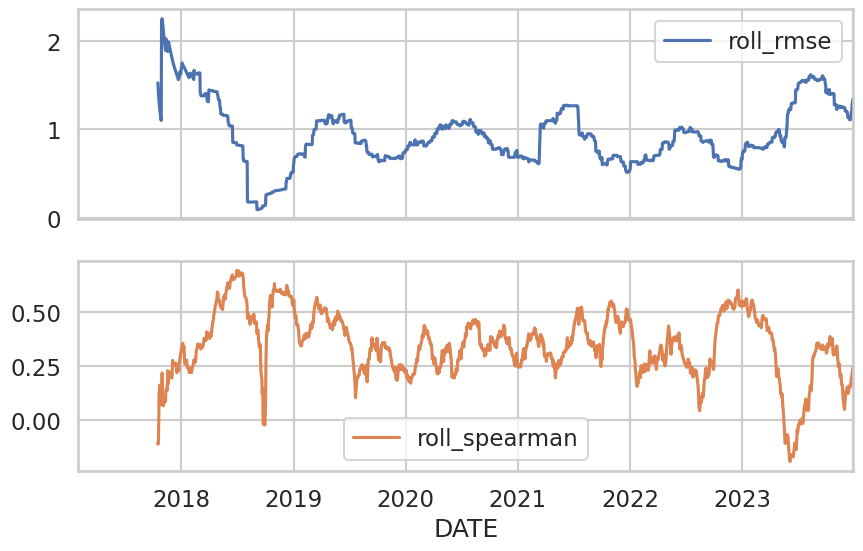

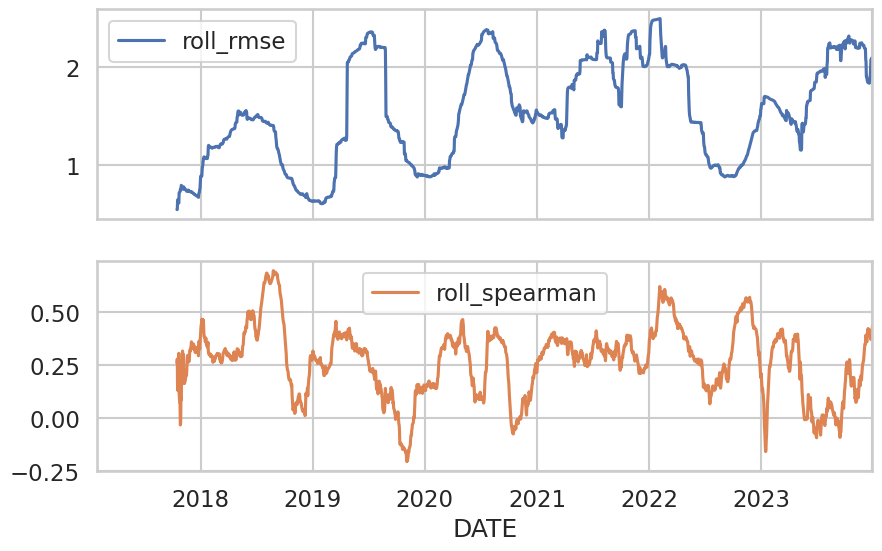

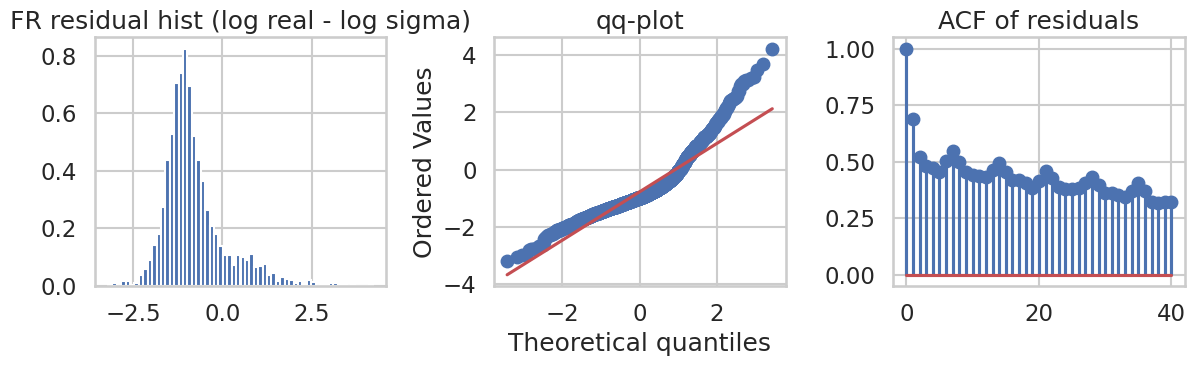

cluster means: -1.098392979239281 0.8243167916914925
cluster sizes: 383 1893
DE residual count 2276 mean=0.6904 std=0.7897 skew=0.2151


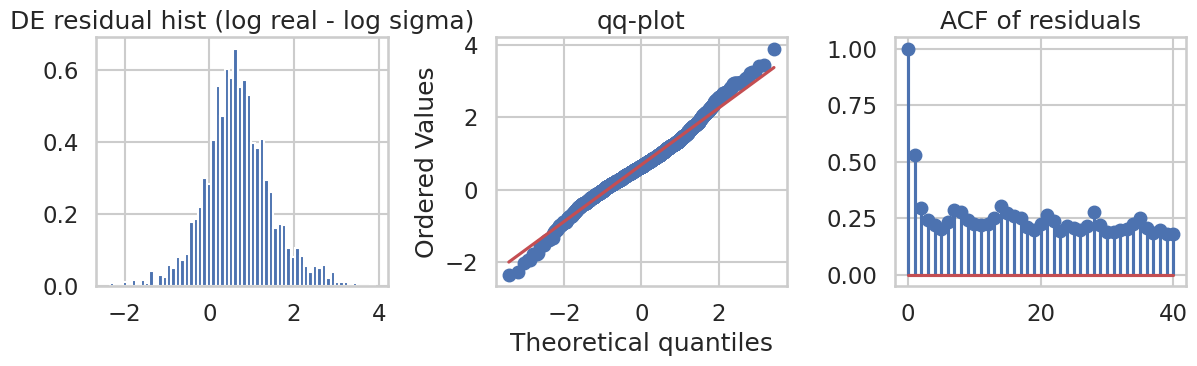

cluster means: 1.3860806729103445 0.17269134280596524
cluster sizes: 1305 971


In [68]:
baseline_check(panel_garch, 'DE')
baseline_check(panel_garch, 'FR')

rg_de = rolling_baseline_metrics(panel_garch, 'DE', window=126)
rg_fr = rolling_baseline_metrics(panel_garch, 'FR', window=126)

rg_de[['roll_rmse','roll_spearman']].plot(subplots=True, figsize=(10,6))
rg_fr[['roll_rmse','roll_spearman']].plot(subplots=True, figsize=(10,6))

baseline_res_diag(panel_garch, 'FR')
baseline_res_diag(panel_garch, 'DE')

### HAR-RV modeling and diagnostics block
- Again, similar observation window structure for Germany and France yielded better results
- This method is definitely superior to GARCH for this data and is used for further steps.
- However, baseline capturing is still imperfect

In [65]:
panel_harrv, metrics_harrv = add_har_rv_parallel(
    panel_feat,
    min_obs = 150,
    window={"DE": 500, "FR": 200}
)
metrics_harrv

{'DE': {'spearman_ic': np.float64(0.5349617057137815),
  'rmse': 0.8505104706093887,
  'mae': 0.48612013542554566},
 'FR': {'spearman_ic': np.float64(0.44469319906770916),
  'rmse': 1.121273012086616,
  'mae': 0.5456783476556731}}

--- DE Baseline check ---
rows: 2526
nan sigma: 150 (5.9%)
nan realized: 0 (0.0%)
valid pairs: 2376
spearman(log realized, log sigma) = 0.5350

--- FR Baseline check ---
rows: 2526
nan sigma: 150 (5.9%)
nan realized: 0 (0.0%)
valid pairs: 2376
spearman(log realized, log sigma) = 0.4447

FR residual count 2376 mean=-0.2064 std=0.6280 skew=0.9269


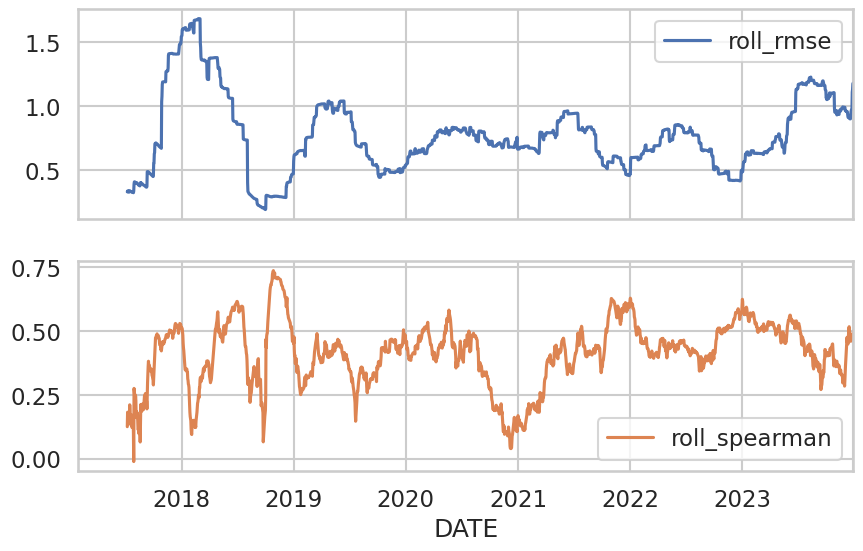

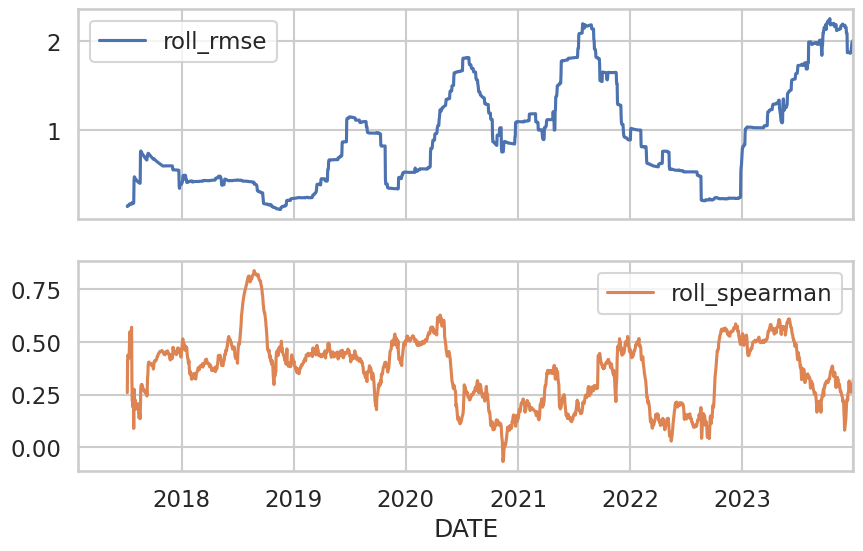

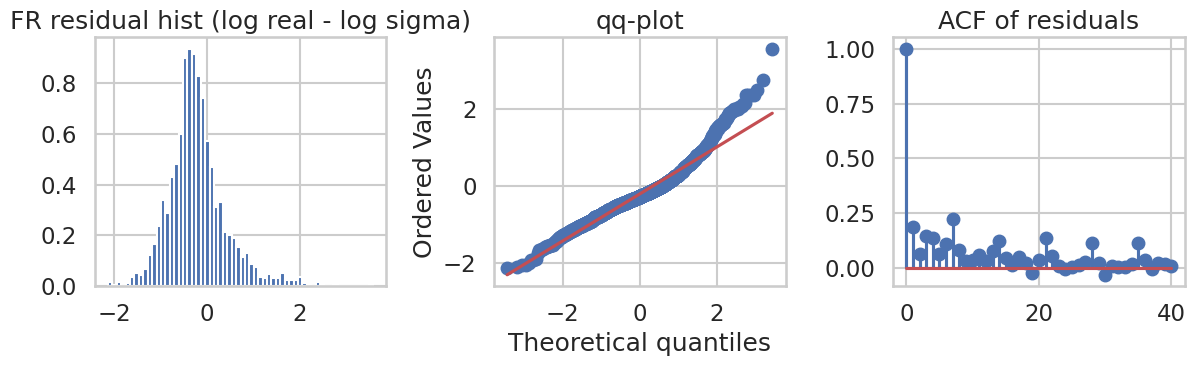

cluster means: -0.4804512235332208 0.602948191934658
cluster sizes: 601 1775
DE residual count 2376 mean=-0.2233 std=0.6110 skew=1.1353


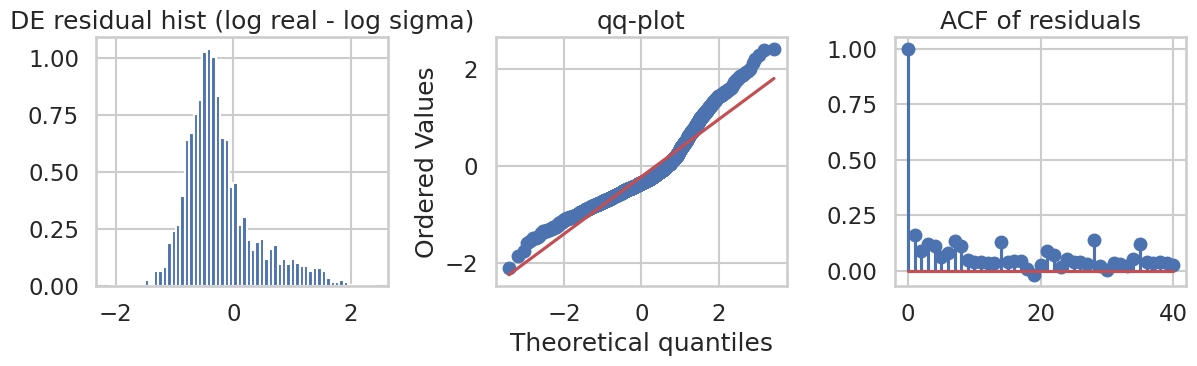

cluster means: -0.4722543554202938 0.7626509538032482
cluster sizes: 479 1897


In [69]:
baseline_check(panel_harrv, 'DE')
baseline_check(panel_harrv, 'FR')

rg_de = rolling_baseline_metrics(panel_harrv, 'DE', window=126)
rg_fr = rolling_baseline_metrics(panel_harrv, 'FR', window=126)

rg_de[['roll_rmse','roll_spearman']].plot(subplots=True, figsize=(10,6))
rg_fr[['roll_rmse','roll_spearman']].plot(subplots=True, figsize=(10,6))

baseline_res_diag(panel_harrv, 'FR')
baseline_res_diag(panel_harrv, 'DE')

### Creating prediction target: computing vol residuals (realized vol - baseline), shifting to t+1

In [72]:
panel_harrv_res = make_t_plus_1_targets_winsorized(panel_harrv, winsor_pct=0)

[target stats] DE_residual_target: n=2376  mean=-0.223  std=0.611  skew=1.135  [-1.28, 1.60]
[target stats] FR_residual_target: n=2376  mean=-0.206  std=0.628  skew=0.927  [-1.54, 1.88]


### Selecting most important features for further ML training
- Quite some overfitting here (train/test IC gap ~0.2), despite heavy regularization and stricter feature pools
- Under further investigation

In [81]:
selected_features, diagnostics = feature_selection(panel_harrv_res)


=== FEATURE SELECTION DIAGNOSTICS ===
Folds: 106
Avg prefilter kept: DE=15.0, FR=15.0
Avg selected (per fold): DE=10.0, FR=10.0
Union selected count: 12

--- Fold-averaged pooled metrics (mean over folds) ---
DE: train pooled IC / RMSE  : 0.5541 0.512
DE: test  pooled IC / RMSE  : 0.3291 0.5132
FR: train pooled IC / RMSE  : 0.4496 0.4696
FR: test  pooled IC / RMSE  : 0.2237 0.5472

Top stable DE selected features (stable_de): ['DE_daily_log_return', 'DE_Fossil_Brown_coal_Lignite_Actual_Aggregated', 'DE_Fossil_Hard_coal_Actual_Aggregated', 'DE_Wind_Offshore_Actual_Aggregated', 'DE_Wind_Onshore_Actual_Aggregated', 'DE_wind_total', 'DE_wind_share']
Top stable FR selected features (stable_fr): ['FR_daily_log_return', 'FR_wind_speed', 'FR_Wind_Onshore_Actual_Aggregated', 'FR_solar_total_rm_7', 'FR_solar_total_rm_30']
Final union (selected_union): ['DE_daily_log_return', 'DE_Fossil_Brown_coal_Lignite_Actual_Aggregated', 'DE_Fossil_Hard_coal_Actual_Aggregated', 'DE_Wind_Offshore_Actual_Aggre

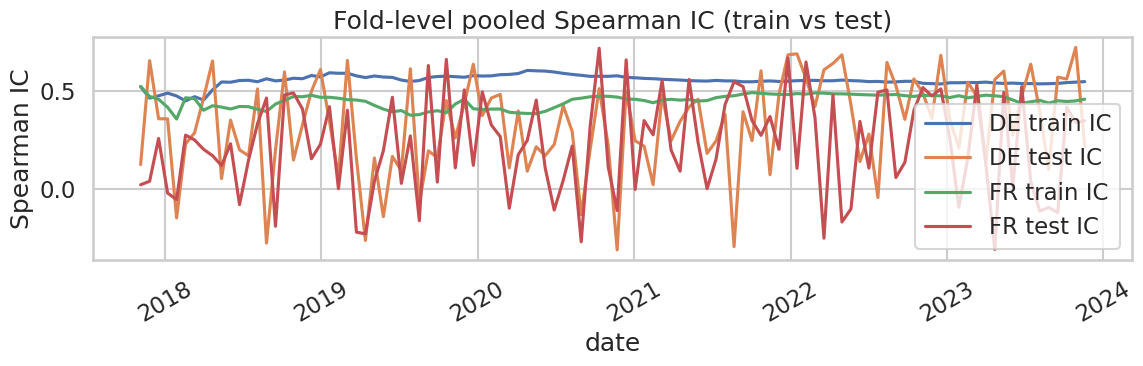

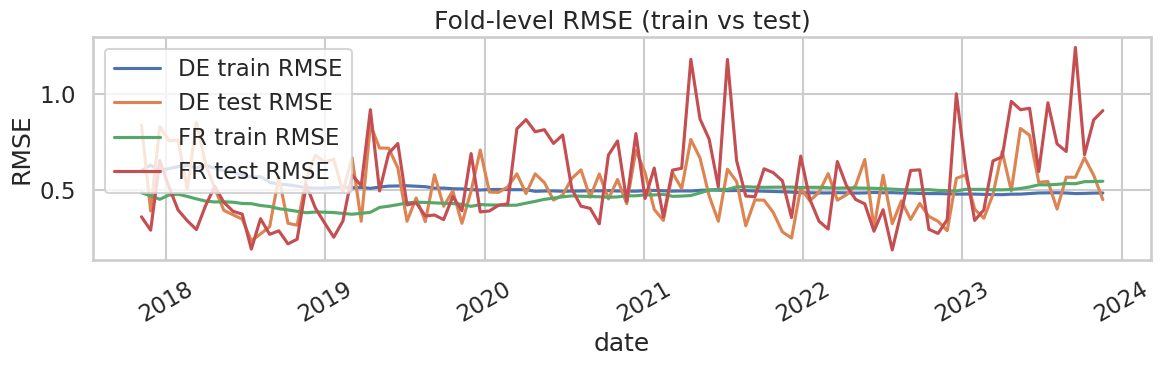

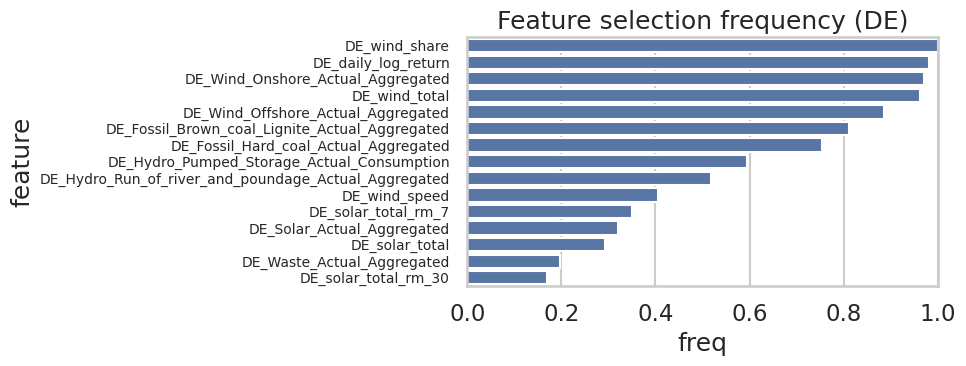

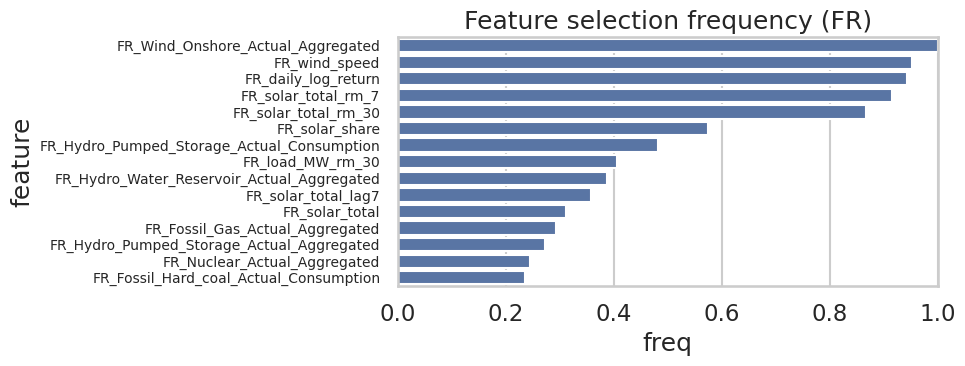

In [83]:
# assume `diagnostics` exists from function call
folds = diagnostics["folds"].copy()
folds["train_until"] = pd.to_datetime(folds["train_until"])

# 1) Train / Test IC over folds
plt.figure(figsize=(12,4))
if "DE_train_ic" in folds:
    sns.lineplot(data=folds, x="train_until", y="DE_train_ic", label="DE train IC")
if "DE_test_ic" in folds:
    sns.lineplot(data=folds, x="train_until", y="DE_test_ic", label="DE test IC")
if "FR_train_ic" in folds:
    sns.lineplot(data=folds, x="train_until", y="FR_train_ic", label="FR train IC")
if "FR_test_ic" in folds:
    sns.lineplot(data=folds, x="train_until", y="FR_test_ic", label="FR test IC")
plt.title("Fold-level pooled Spearman IC (train vs test)")
plt.ylabel('Spearman IC')
plt.xlabel('date')
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()

# 2) Train / Test RMSE over folds
plt.figure(figsize=(12,4))
if "DE_train_rmse" in folds:
    sns.lineplot(data=folds, x="train_until", y="DE_train_rmse", label="DE train RMSE")
if "DE_test_rmse" in folds:
    sns.lineplot(data=folds, x="train_until", y="DE_test_rmse", label="DE test RMSE")
if "FR_train_rmse" in folds:
    sns.lineplot(data=folds, x="train_until", y="FR_train_rmse", label="FR train RMSE")
if "FR_test_rmse" in folds:
    sns.lineplot(data=folds, x="train_until", y="FR_test_rmse", label="FR test RMSE")
plt.title("Fold-level RMSE (train vs test)")
plt.ylabel('RMSE')
plt.xlabel('date')
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

# 3) Feature selection frequency (top 15) per country
freq_de = diagnostics.get("freq_de", {})
freq_fr = diagnostics.get("freq_fr", {})
def plot_top_freq(freq_map, title, top_n=15):
    if not freq_map:
        print("No freq data for", title)
        return
    df_freq = pd.DataFrame(list(freq_map.items()), columns=["feature","freq"])
    df_freq = df_freq.sort_values("freq", ascending=False).head(top_n)
    plt.figure(figsize=(10, max(4, 0.2*len(df_freq))))
    sns.barplot(x="freq", y="feature", data=df_freq)
    plt.yticks(fontsize=10) 
    plt.title(title)
    plt.xlim(0,1)
    plt.tight_layout()
    plt.show()

plot_top_freq(freq_de, "Feature selection frequency (DE)")
plot_top_freq(freq_fr, "Feature selection frequency (FR)")

# 4) If you have predictions (all_preds DataFrame with DATE, COUNTRY, pred, true):
#    scatter plot pred vs true (residuals)
if 'all_preds' in globals():
    allp = all_preds.copy()
    allp['DATE'] = pd.to_datetime(allp['DATE'])
    for c in ["DE","FR"]:
        sub = allp[allp["COUNTRY"]==c]
        if sub.shape[0] == 0:
            continue
        plt.figure(figsize=(6,6))
        sns.scatterplot(x="true", y="pred", data=sub, alpha=0.5)
        #plt.plot([sub["true"].min(), sub["true"].max()], [sub["true"].min(), sub["true"].max()], linestyle="--", color="gray")
        plt.title(f"{c}: Predictions vs True")
        #plt.xlim(-4,4)
        #plt.ylim(-2,2)
        plt.xlabel("True")
        plt.ylabel("Pred")
        plt.tight_layout()
        plt.show()

        # show simple pooled metrics for this country
        mask = (~sub["pred"].isna()) & (~sub["true"].isna())
        if mask.sum()>0:
            from scipy.stats import spearmanr
            ic = spearmanr(sub.loc[mask,"pred"], sub.loc[mask,"true"]).correlation
            rmse = np.sqrt(((sub.loc[mask,"pred"]-sub.loc[mask,"true"])**2).mean())
            mae = np.mean(np.abs(sub.loc[mask,"pred"]-sub.loc[mask,"true"]))
            print(f"{c} pooled: n={mask.sum()}, spearman_ic={ic:.4f}, rmse={rmse:.4f}, mae={mae:.4f}")

### An example of HMM regime detection for France and diagnostics
- Just a demo here, used on full data sample
- This function is further used in the exp. window logic with XGBoost to avoid lookahead

In [85]:
fr_regimes, fr_diag = detect_markov_regime(
    panel_harrv_res,
    residual_col="FR_residual_target"
)

print(fr_diag["transition_matrix"])
print(fr_diag["means"])
print(fr_diag["state_counts"])

[[0.93429913 0.06570087]
 [0.0499296  0.9500704 ]]
[ 0.03967559 -0.02981126]
[1012 1364]


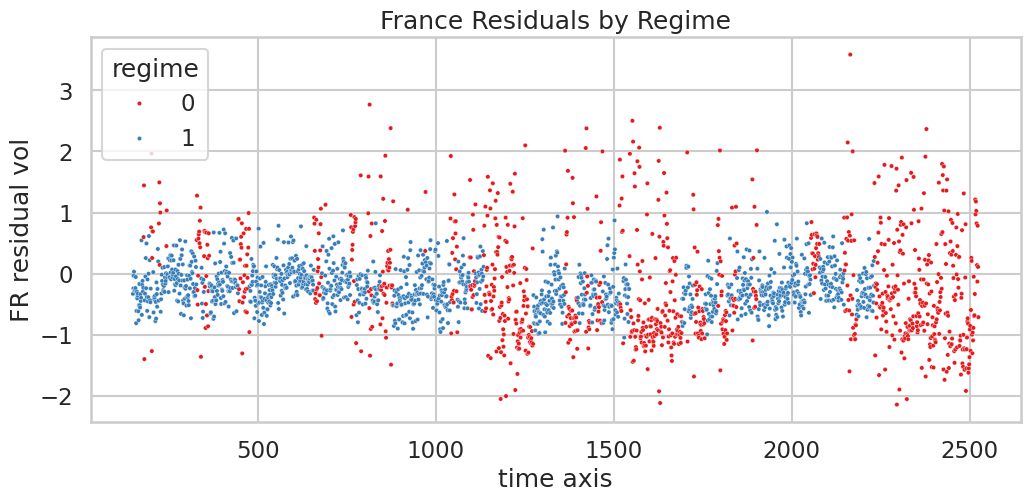

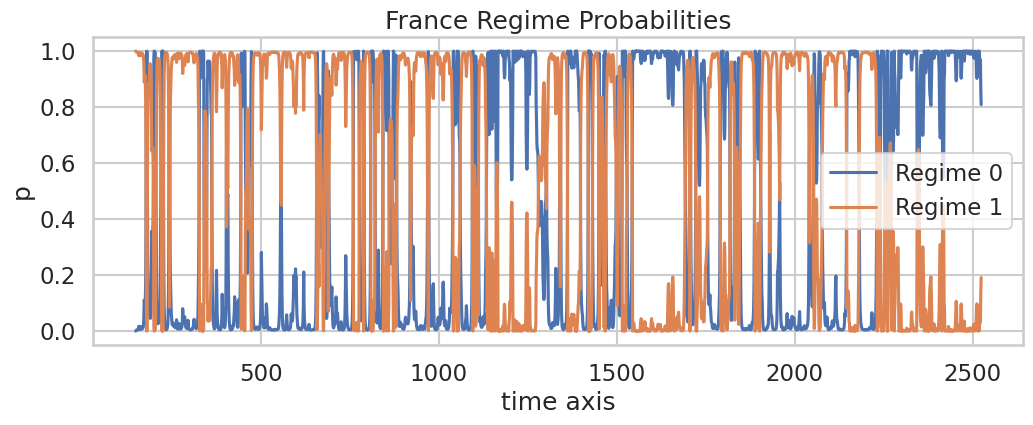

In [90]:
plt.figure(figsize=(12,5))
sns.scatterplot(x=fr_regimes.index,
    y=fr_regimes["FR_residual_target"],
    hue=fr_regimes["regime"],
    palette="Set1",
    s=10
)
plt.title("France Residuals by Regime")
plt.ylabel('FR residual vol')
plt.xlabel('time axis')


plt.figure(figsize=(12,4))
plt.plot(fr_regimes.index, fr_regimes["regime_prob_0"], label="Regime 0")
plt.plot(fr_regimes.index, fr_regimes["regime_prob_1"], label="Regime 1")
plt.xlabel('time axis')
plt.ylabel('p')

plt.legend()
plt.title("France Regime Probabilities");

{np.float64(0.0): {'n_obs': 1012, 'acf_lag1': 0.17035698352885023, 'acf_full': array([1.        , 0.17035698, 0.07314417, 0.17446438, 0.13357326,
       0.05830277])}, np.float64(1.0): {'n_obs': 1364, 'acf_lag1': 0.2260892712221761, 'acf_full': array([1.        , 0.22608927, 0.15694551, 0.1748838 , 0.16513742,
       0.13649872])}}


<Figure size 600x400 with 0 Axes>

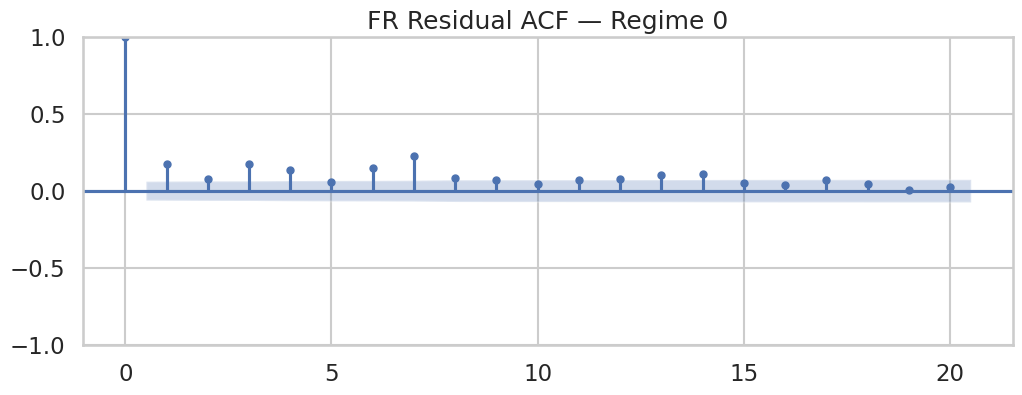

<Figure size 600x400 with 0 Axes>

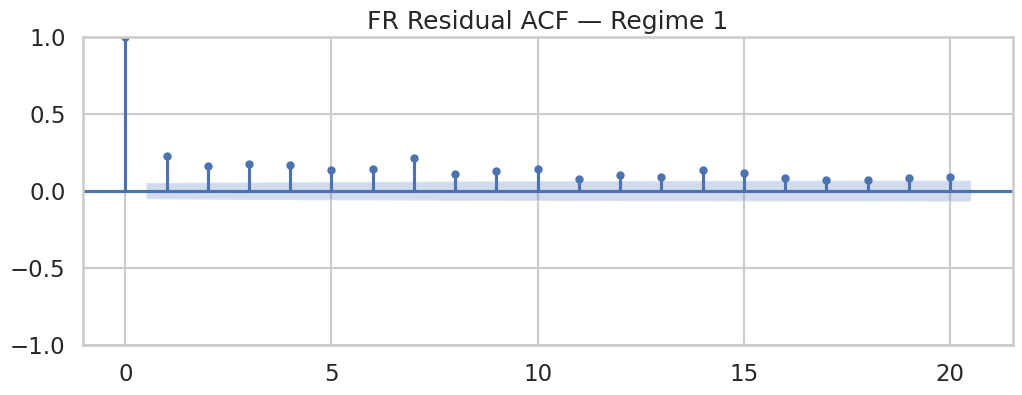

In [97]:
# merge regime labels back into main df
panel_harrv_res_regimes = panel_harrv_res.copy()
panel_harrv_res_regimes["FR_regime"] = np.nan

panel_harrv_res_regimes.loc[fr_regimes.index, "FR_regime"] = fr_regimes["regime"]

acf_results = compute_acf_by_regime(
    panel_harrv_res_regimes,
    residual_col="FR_residual_target",
    regime_col="FR_regime",
    max_lag=5
)

print(acf_results)

for regime in sorted(panel_harrv_res_regimes["FR_regime"].dropna().unique()):
    subset = panel_harrv_res_regimes[panel_harrv_res_regimes["FR_regime"] == regime]["FR_residual_target"].dropna()
    
    plt.figure(figsize=(6,4))
    plot_acf(subset, lags=20)
    plt.title(f"FR Residual ACF — Regime {int(regime)}")

### Main XGBoost residual vol forecasting block and diagnostics
- Here again, plagued by overfitting (IC train/test gap of ~0.2, retention 55%-60% of training on test). Need more robust procedure. Also check hyperparameter selection. Ideally would have 0.05-0.15 gap, that is, 70%-85% retention.

In [99]:
all_preds, cv_metrics = two_regime_expanding_cv_per_country(
    panel_harrv_res, selected_features,
    use_markov={'DE': False, 'FR': True},
    k_regimes=2, n_jobs=-1
)

=== SUMMARY ===
Pooled IC: 0.3714043755678792
Per-country IC: {'DE': 0.3761571104841529, 'FR': 0.3183500421552978}
Mean fold ICs: 0.306108888233642 0.20533396619292518
Mean RMSE (fold mean): 0.539312037903931
Pooled RMSE / MAE: 0.5722297442317212 0.42477848923085254


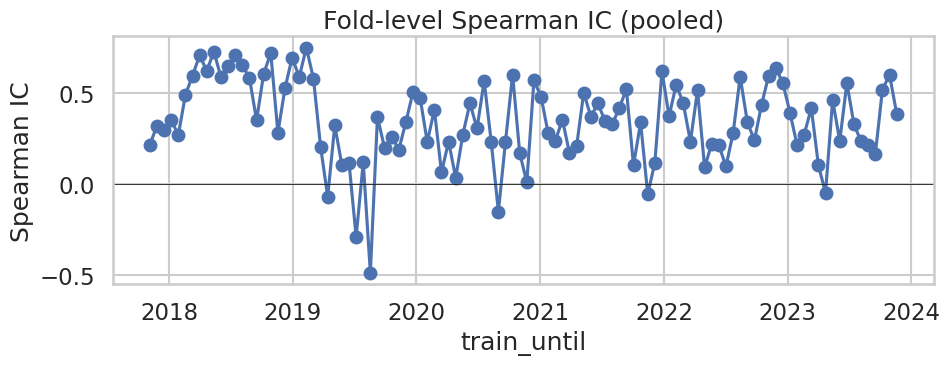

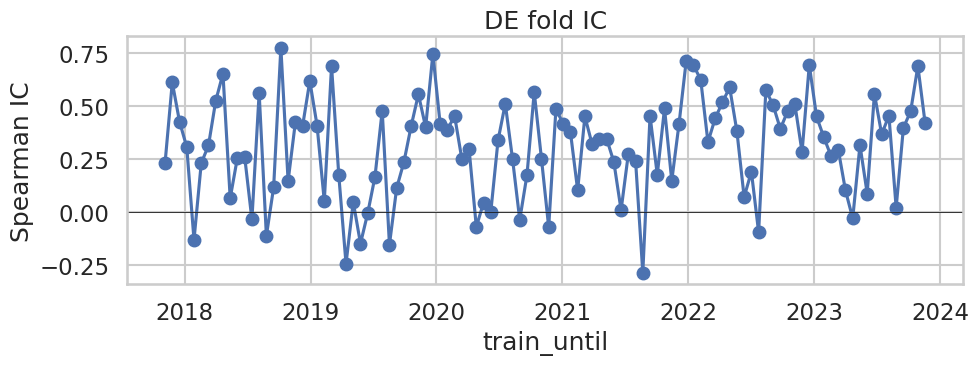

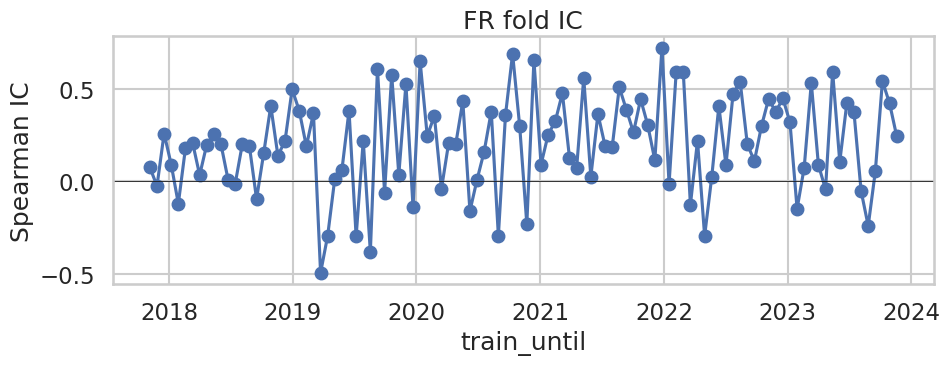

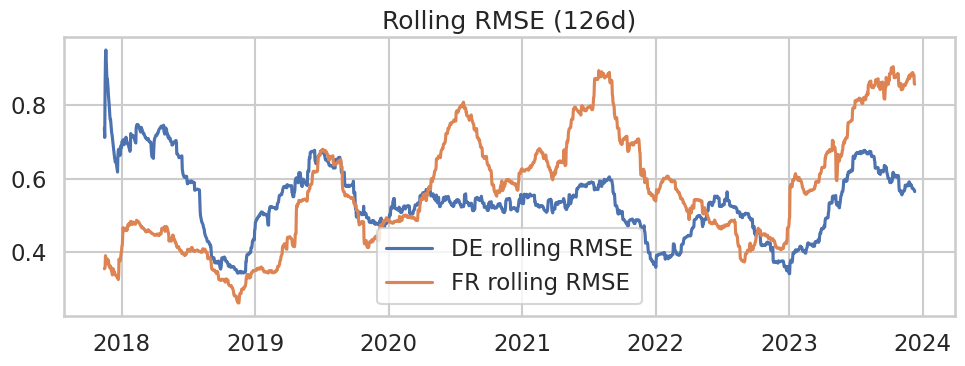

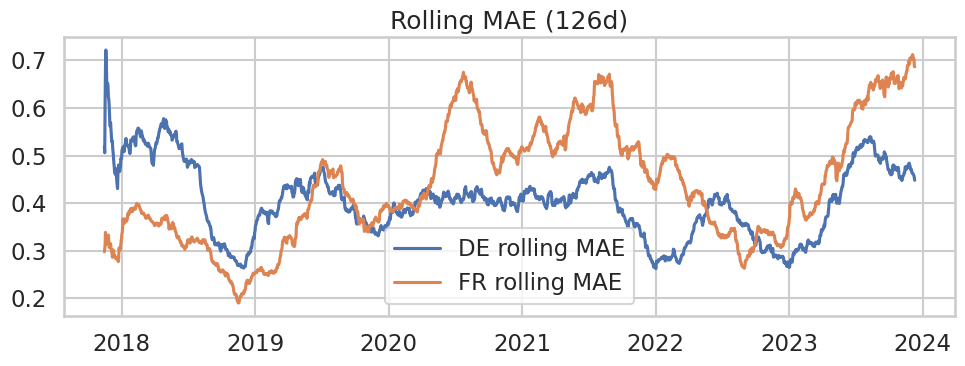

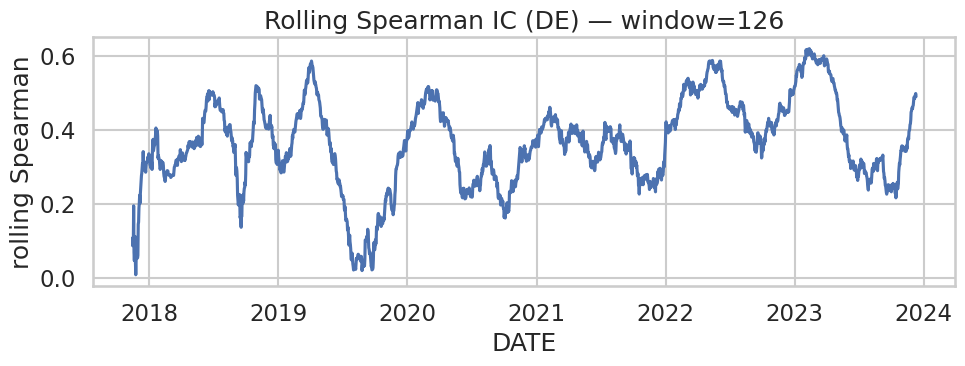

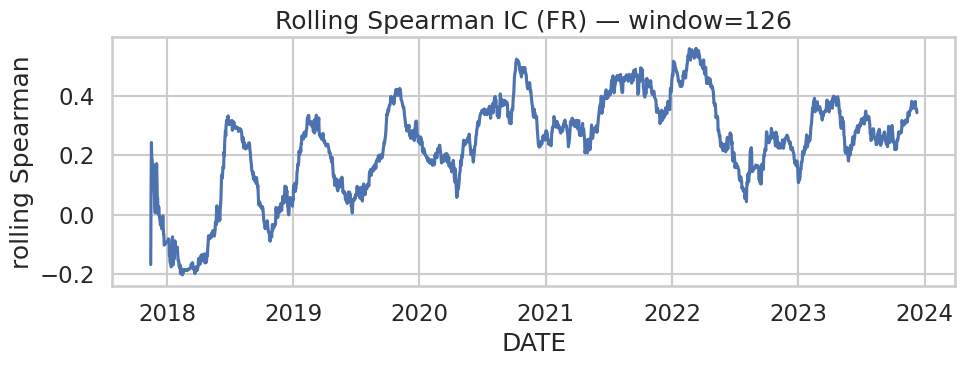

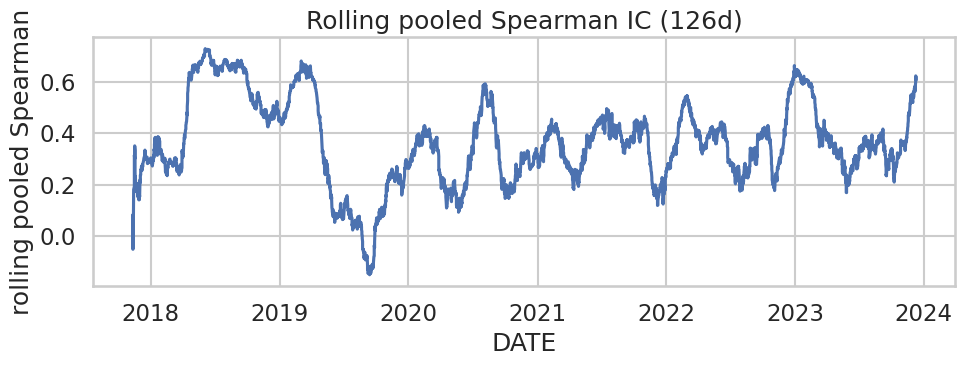

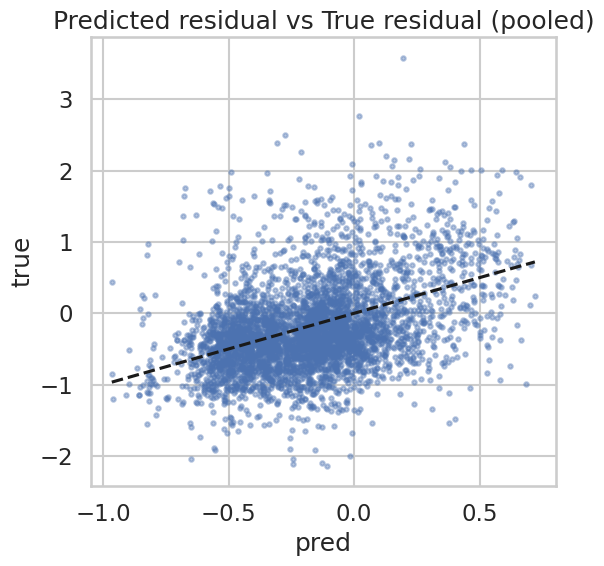

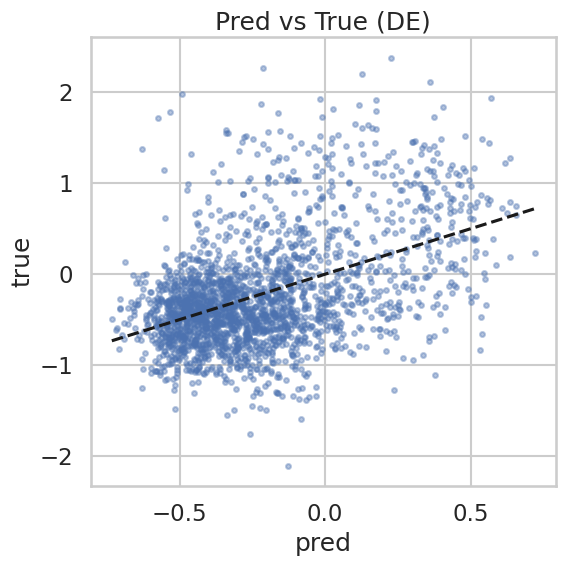

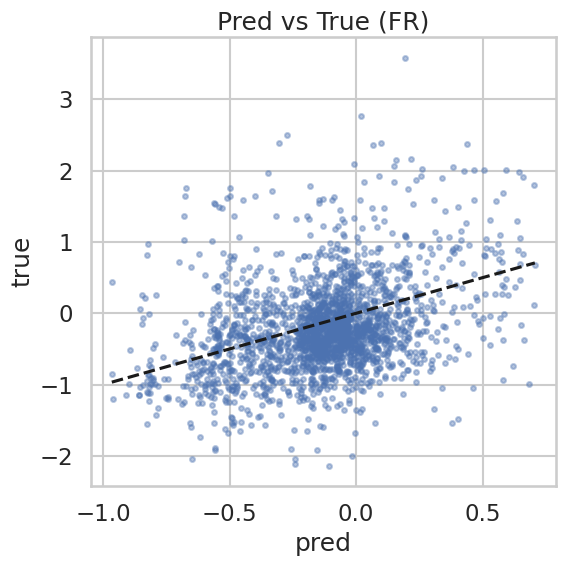

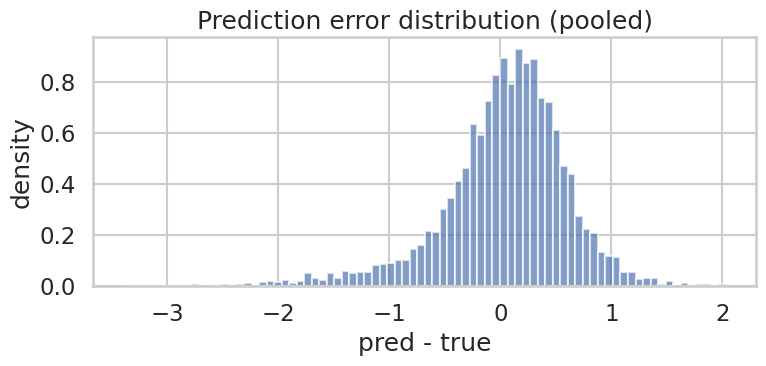

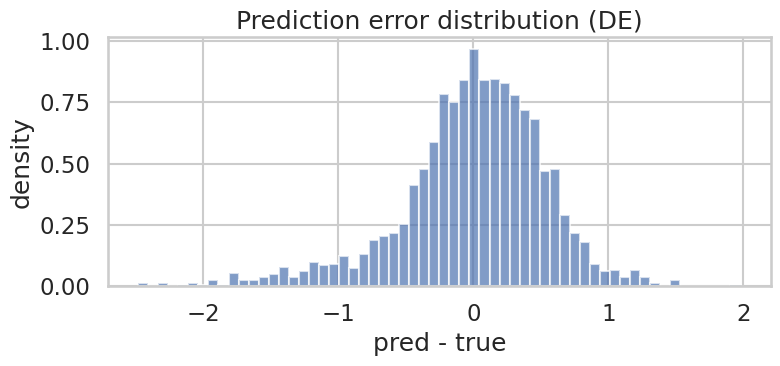

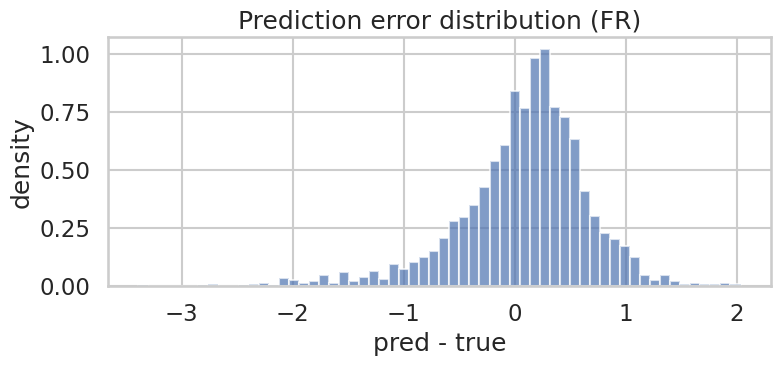

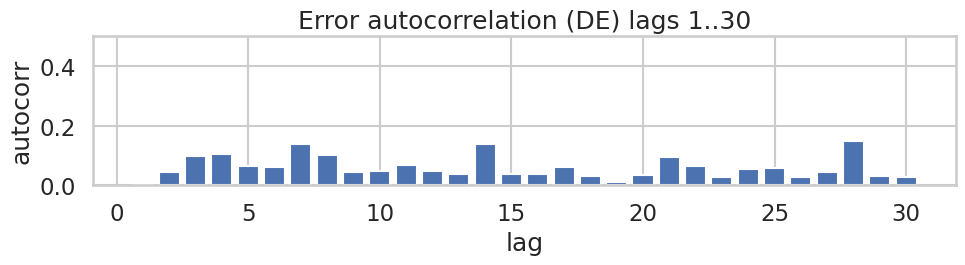

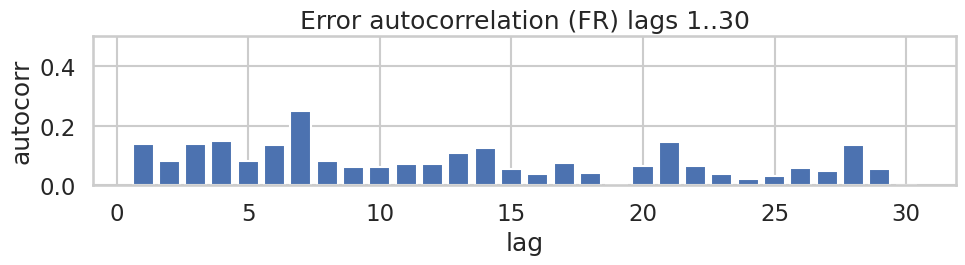

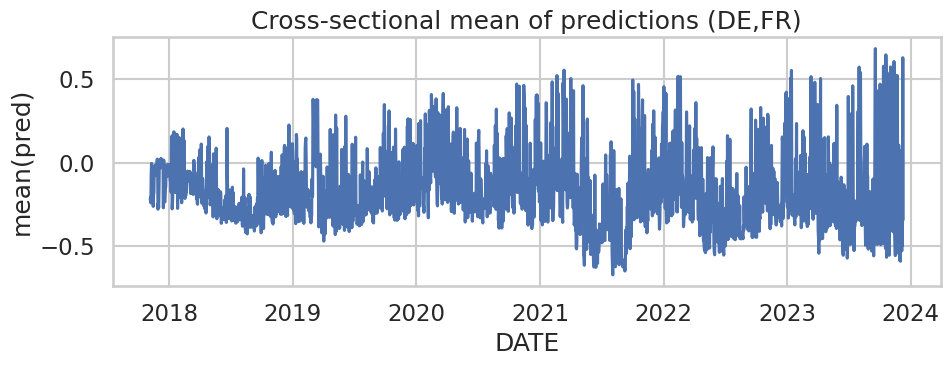

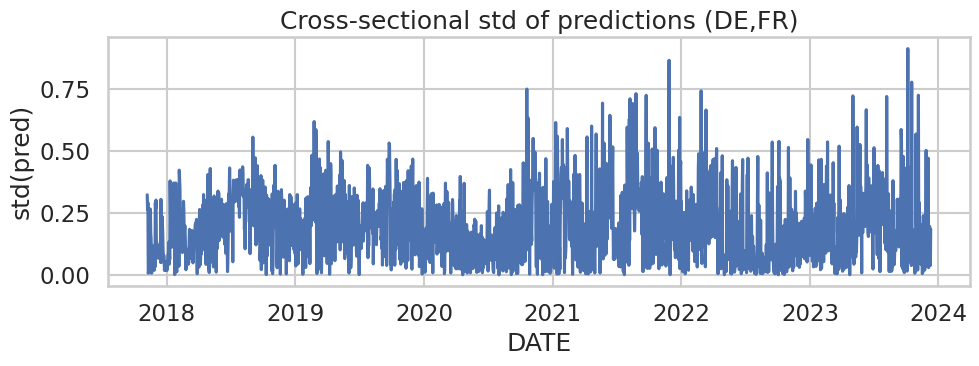

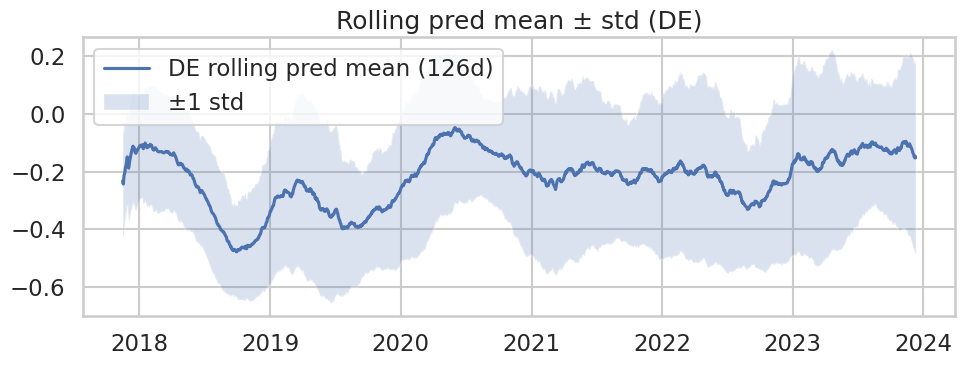

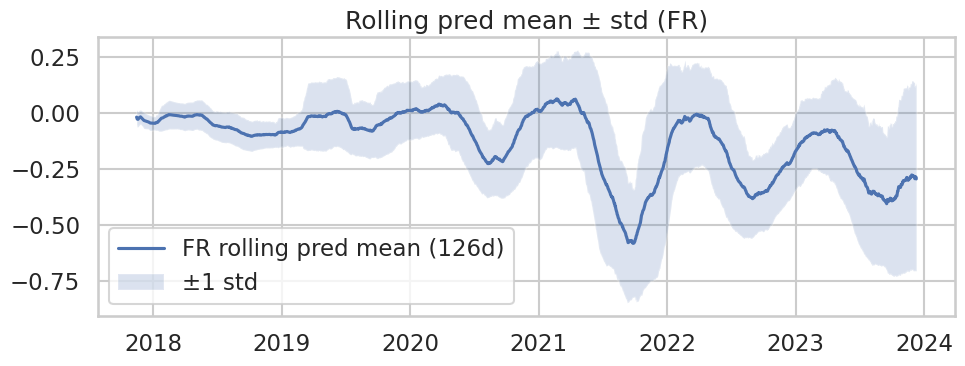

In [100]:
plot_cv_diagnostics(all_preds, cv_metrics)

train IC: 0.485
val IC: 0.275
diff. IC train-val: 0.21


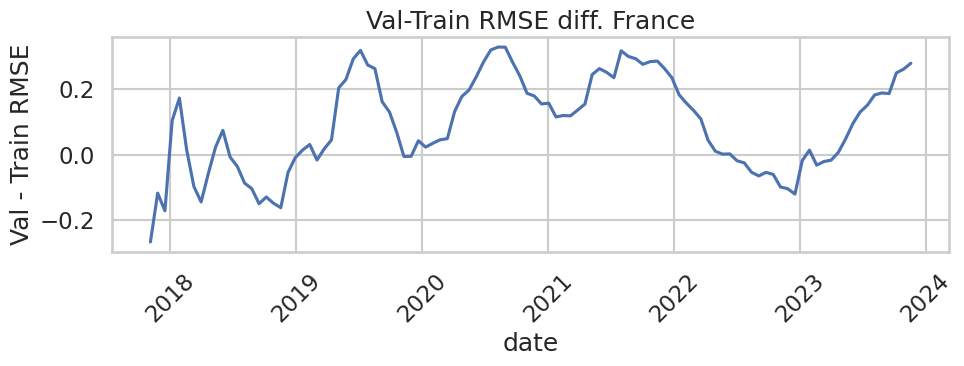

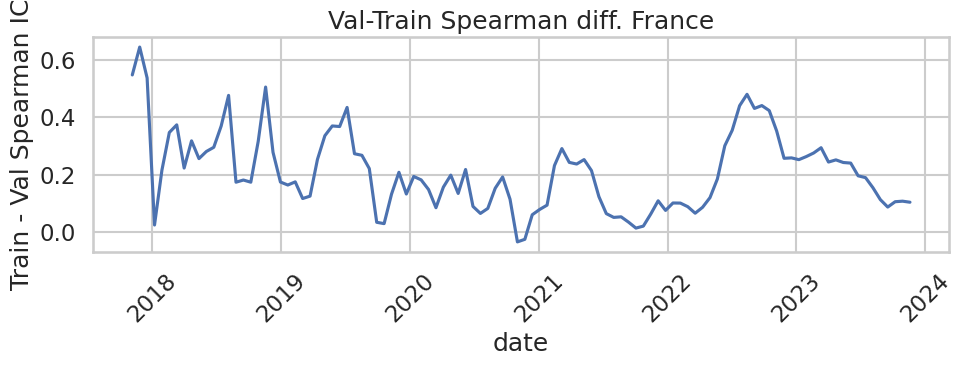

In [114]:
plt.figure(figsize=(10,4))
folds = cv_metrics.get('folds', pd.DataFrame())
sns.lineplot(x=pd.to_datetime(folds["train_until"]),
             y=folds["val_rmse_pre_exp_fr"]-folds["train_rmse_pre_exp_fr"],
             #label="(Val - Train) RMSE")
#sns.lineplot(x=pd.to_datetime(folds["train_until"]),
#             y=folds["val_rmse_pre_exp_fr"],
#             label="Val RMSE (Exp)"
            )
plt.title("Val-Train RMSE diff. France")
plt.xlabel('date')
plt.ylabel('Val - Train RMSE')
plt.xticks(rotation=45)
plt.tight_layout()

plt.figure(figsize=(10,4))
folds = cv_metrics.get('folds', pd.DataFrame())
sns.lineplot(x=pd.to_datetime(folds["train_until"]),
             y=folds["train_ic_pre_exp_fr"]-folds["val_ic_pre_exp_fr"],
             #label="Train - Val IC (train/test gap)"
            )
#sns.lineplot(x=pd.to_datetime(folds["train_until"]),
#             y=folds["val_ic_pre_exp_fr"],
#             label="Val RMSE (Exp)")
plt.title("Val-Train Spearman diff. France")
plt.xlabel('date')
plt.ylabel('Train - Val Spearman IC')
plt.xticks(rotation=45)
plt.tight_layout()

print('train IC:', round(np.mean(cv_metrics['folds']['train_ic_pre_exp_fr']), 3)) 
print('val IC:', round(np.mean(cv_metrics['folds']['val_ic_pre_exp_fr']),3)  )
print('diff. IC train-val:', 
     round( np.mean(cv_metrics['folds']['train_ic_pre_exp_fr'])-np.mean(cv_metrics['folds']['val_ic_pre_exp_fr']), 3)
     )

### Trading strategy + diagnostics block 
- Input definitely needs to improve

In [134]:
bt = compute_market_neutral_pnl_adaptive(all_preds)#, ewma_alpha = 0.1, rebalance_thr = 0.01, lookback=30)

In [135]:
diag = evaluate_trading_performance(bt)

=== Trading Performance ===
Sharpe Ratio: 0.9447
Max Drawdown: -7.3097
Win Rate: 43.80%
Avg Daily Turnover: 0.7772
Total PnL: 35.037613
Total Cost: 0.865000
PnL Before Cost: 35.902613


In [136]:
daily_pnl = bt.groupby('DATE')['pnl'].sum()
print(daily_pnl.quantile([0.1, 0.25, 0.5, 0.75, 0.9]))

left = abs(daily_pnl.quantile(0.1))
right = daily_pnl.quantile(0.9)
print("Asymmetry ratio (right/left):", right/left)

0.10   -0.281482
0.25   -0.125611
0.50   -0.000500
0.75    0.142151
0.90    0.329979
Name: pnl, dtype: float64
Asymmetry ratio (right/left): 1.172290544972303


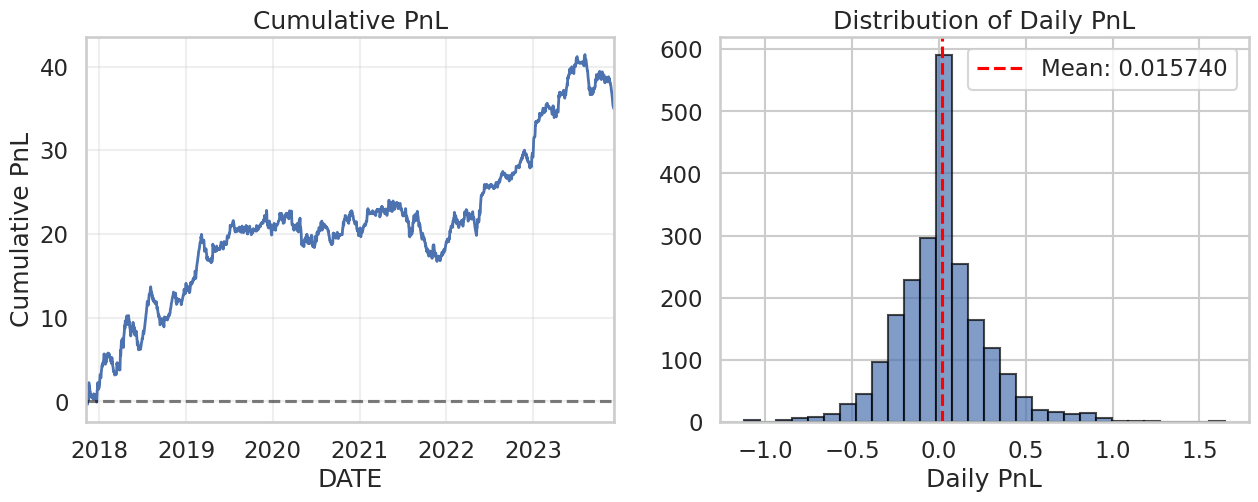

In [137]:
# 3. Cumulative PnL
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
cum_pnl = daily_pnl.cumsum()
cum_pnl.plot(ax=axes[0], title='Cumulative PnL', linewidth=2)
axes[0].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[0].set_ylabel('Cumulative PnL')
axes[0].grid(True, alpha=0.3)

# 4. Daily PnL distribution
axes[1].hist(daily_pnl.dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(daily_pnl.mean(), color='red', linestyle='--',
                   label=f'Mean: {daily_pnl.mean():.6f}')
axes[1].set_title('Distribution of Daily PnL')
axes[1].set_xlabel('Daily PnL')
axes[1].legend();